### Simple Transformer

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import math
from sklearn.model_selection import train_test_split
import time

# Positional Encoding
class PositionalEncoding(nn.Module):
    """
    Positional encoding for transformer sequence data.
    Adds information about the position of each element in the sequence.
    """
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create positional encoding matrix
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))

        # Initialize positional encoding buffer
        pe = torch.zeros(max_len, d_model)

        # Sine for even indices, cosine for odd indices
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Register as buffer (not a parameter)
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        Args:
            x: Tensor, shape [batch_size, seq_len, embedding_dim]
        Returns:
            Tensor with positional encoding added, same shape as x
        """
        # Add positional encoding to input tensor
        x = x + self.pe[:x.size(1)]

        # Apply dropout
        return self.dropout(x)

class SimpleVelocityTransformer(nn.Module):
    def __init__(self, input_dims, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super(SimpleVelocityTransformer, self).__init__()

        # Input embeddings for each motion type
        self.embeddings = nn.ModuleDict()
        for name, dim in input_dims.items():
            self.embeddings[name] = nn.Linear(dim, d_model)

        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model, dropout)

        # Transformer encoder layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model*2,
            dropout=dropout,
            batch_first=True
        )

        # Transformer encoder
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # Output layer for velocity prediction
        self.velocity_head = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, sequences):
        # Process each motion type
        embedded_sequences = []
        sequence_lengths = []

        # Embed each sequence type
        for name, sequence in sequences.items():
            if sequence is not None and sequence.size(1) > 0:  # Check if sequence exists and has data
                embedded = self.embeddings[name](sequence)
                embedded = self.pos_encoder(embedded)
                embedded_sequences.append(embedded)
                sequence_lengths.append(embedded.shape[1])

        if not embedded_sequences:
            # Handle case with no valid sequences
            batch_size = next(iter(sequences.values())).shape[0]
            return torch.zeros(batch_size, 1, device=next(iter(sequences.values())).device)

        # Concatenate all sequences along the time dimension
        # This simplifies by treating all motion types as one longer sequence
        concat_sequence = torch.cat(embedded_sequences, dim=1)

        # Apply transformer encoder
        transformed = self.transformer_encoder(concat_sequence)

        # Global pooling over the sequence dimension
        pooled = transformed.mean(dim=1)

        # Predict velocity
        velocity = self.velocity_head(pooled)

        return velocity

# Same dataset class from your original code
class EnhancedPitchingDataset(Dataset):
    def __init__(self, processed_pitches, max_seq_length=500):
        self.processed_pitches = processed_pitches
        self.max_seq_length = max_seq_length

        # Find all motion types
        all_motion_types = set()
        for pitch in processed_pitches:
            all_motion_types.update(pitch['sequences'].keys())
        self.motion_types = sorted(all_motion_types)

        # Calculate feature dimensions
        self.feature_dims = {}
        for mt in self.motion_types:
            for pitch in processed_pitches:
                if mt in pitch['sequences']:
                    self.feature_dims[mt] = pitch['sequences'][mt].shape[1]
                    break

        print(f"Dataset created with {len(processed_pitches)} pitches")
        print(f"Motion types: {self.motion_types}")
        print(f"Feature dimensions: {self.feature_dims}")

    def __len__(self):
        return len(self.processed_pitches)

    def __getitem__(self, idx):
        pitch = self.processed_pitches[idx]

        # Process each motion type separately
        sequences = {}
        masks = {}

        for mt in self.motion_types:
            if mt in pitch['sequences']:
                # Get sequence data
                sequence = pitch['sequences'][mt]

                # Handle sequence length
                seq_len = min(sequence.shape[0], self.max_seq_length)
                padded_sequence = np.zeros((self.max_seq_length, sequence.shape[1]))
                padded_sequence[:seq_len] = sequence[:seq_len]

                # Create mask (1 for real data, 0 for padding)
                mask = np.zeros(self.max_seq_length)
                mask[:seq_len] = 1

                # Add to dictionary
                sequences[mt] = padded_sequence
                masks[mt] = mask
            else:
                # Use dummy data for missing types
                if mt in self.feature_dims:
                    feature_dim = self.feature_dims[mt]
                    sequences[mt] = np.zeros((self.max_seq_length, feature_dim))
                    masks[mt] = np.zeros(self.max_seq_length)

        # Convert to tensors
        tensor_sequences = {
            mt: torch.FloatTensor(sequences[mt]) for mt in sequences
        }

        tensor_masks = {
            mt: torch.FloatTensor(masks[mt]) for mt in masks
        }

        return {
            'sequences': tensor_sequences,
            'masks': tensor_masks,
            'velocity': torch.FloatTensor([pitch['velocity']]),
            'pitch_id': pitch['pitch_id']
        }

# Data loading and preprocessing (reused from your code)
def load_and_process_data(data_dir):
    """Load and preprocess pitching data from CSV files"""
    print(f"Loading data from {data_dir}")

    # Load POI metrics (contains velocity)
    poi_path = os.path.join(data_dir, 'poi_metrics.csv')
    poi_df = pd.read_csv(poi_path)
    print(f"Loaded POI data: {poi_df.shape}")

    # Load motion data files
    motion_data = {}
    for filename in ['energy_flow.csv', 'force_plate.csv', 'forces_moments.csv',
                    'joint_angles.csv', 'joint_velos.csv', 'landmarks.csv']:
        try:
            filepath = os.path.join(data_dir, filename)
            if os.path.exists(filepath):
                df = pd.read_csv(filepath)
                name = os.path.splitext(filename)[0]
                motion_data[name] = df
                print(f"Loaded {name}: {df.shape}")
        except Exception as e:
            print(f"Error loading {filename}: {e}")

    # Process data
    processed_pitches = preprocess_data(poi_df, motion_data)

    return processed_pitches

def preprocess_data(poi_df, motion_data, pitch_id_col='session_pitch', velocity_col='pitch_speed_mph'):
    """Preprocess pitching data"""
    processed_pitches = []

    # Get unique pitches with velocity data
    unique_pitches = poi_df[pitch_id_col].unique()
    print(f"Processing {len(unique_pitches)} unique pitches")

    for pitch_id in unique_pitches:
        try:
            # Get velocity
            pitch_row = poi_df[poi_df[pitch_id_col] == pitch_id]
            if pitch_row.empty:
                continue

            if velocity_col not in pitch_row.columns:
                print(f"ERROR: Velocity column '{velocity_col}' not found in columns: {pitch_row.columns}")
                continue

            velocity = float(pitch_row[velocity_col].values[0])

            # Skip pitches with invalid velocity
            if np.isnan(velocity) or velocity <= 0 or velocity > 120:
                print(f"Skipping pitch {pitch_id} with invalid velocity: {velocity}")
                continue

            # Process sequences
            sequences = {}

            for name, df in motion_data.items():
                # Get data for this pitch
                pitch_df = df[df[pitch_id_col] == pitch_id].copy()

                if pitch_df.empty:
                    continue

                # Keep only numeric columns except pitch_id
                numeric_cols = [col for col in pitch_df.columns
                               if pd.api.types.is_numeric_dtype(df[col])
                               and col != pitch_id_col]

                if not numeric_cols:
                    continue

                # Extract sequence and handle NaN values
                sequence = pitch_df[numeric_cols].values

                # Skip sequences with all NaN values in any column
                if np.isnan(sequence).all(axis=0).any():
                    continue

                # Replace remaining NaN values with 0
                sequence = np.nan_to_num(sequence, nan=0.0)

                # Normalize the sequence (simple min-max scaling per feature)
                for j in range(sequence.shape[1]):
                    col_min = sequence[:, j].min()
                    col_max = sequence[:, j].max()
                    if col_max > col_min:
                        sequence[:, j] = (sequence[:, j] - col_min) / (col_max - col_min)

                sequences[name] = sequence

            # Only keep pitches with motion data
            if sequences:
                processed_pitch = {
                    'pitch_id': pitch_id,
                    'velocity': velocity,
                    'sequences': sequences
                }
                processed_pitches.append(processed_pitch)

        except Exception as e:
            print(f"Error processing pitch {pitch_id}: {e}")

    print(f"Successfully processed {len(processed_pitches)} pitches")
    return processed_pitches

# Training function with simpler approach
def train_model(model, train_loader, val_loader, epochs=50, lr=1e-4, device='cuda'):
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    # Optimizer with higher learning rate
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0.001)

    # OneCycleLR scheduler for faster convergence
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=lr*3,  # Peak learning rate
        total_steps=epochs * len(train_loader),
        pct_start=0.2,  # 20% warmup
        div_factor=10,  # initial_lr = max_lr/div_factor
        final_div_factor=100,  # final_lr = max_lr/final_div_factor
        anneal_strategy='cos'
    )

    # Loss function
    mse_loss = nn.MSELoss()

    # Training loop
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_state = None
    best_epoch = 0
    patience = 10
    patience_counter = 0

    for epoch in range(epochs):
        # Training
        model.train()
        epoch_loss = 0
        batch_count = 0

        for batch in train_loader:
            # Get data
            sequences = {
                mt: batch['sequences'][mt].to(device)
                for mt in batch['sequences']
            }
            velocity = batch['velocity'].to(device)

            # Forward pass
            optimizer.zero_grad()
            pred_velocity = model(sequences)
            loss = mse_loss(pred_velocity, velocity)

            # Backward pass
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            # Update weights
            optimizer.step()

            # Step the scheduler (per batch)
            scheduler.step()

            # Track losses
            epoch_loss += loss.item()
            batch_count += 1

        # Calculate average loss
        avg_train_loss = epoch_loss / batch_count
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        val_loss = 0
        val_batch_count = 0

        with torch.no_grad():
            for batch in val_loader:
                # Get data
                sequences = {
                    mt: batch['sequences'][mt].to(device)
                    for mt in batch['sequences']
                }
                velocity = batch['velocity'].to(device)

                # Forward pass
                pred_velocity = model(sequences)
                loss = mse_loss(pred_velocity, velocity)

                val_loss += loss.item()
                val_batch_count += 1

        # Calculate average validation loss
        avg_val_loss = val_loss / val_batch_count
        val_losses.append(avg_val_loss)

        # Learning rate is already updated per batch with OneCycleLR

        # Print progress
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # Check if this is the best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict().copy()
            best_epoch = epoch
            patience_counter = 0
            print(f"  New best model with val loss: {best_val_loss:.4f}")
        else:
            patience_counter += 1

        # Early stopping
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break

    # Save the best model
    if best_model_state is not None:
        torch.save({
            'epoch': best_epoch,
            'model_state_dict': best_model_state,
            'val_loss': best_val_loss,
        }, 'best_simple_transformer_model.pt')
        print(f"Saved best model from epoch {best_epoch+1} with val loss: {best_val_loss:.4f}")

    return train_losses, val_losses, best_epoch

def evaluate_model(model, test_loader, device='cpu'):
    model = model.to(device)
    model.eval()

    mse_loss = nn.MSELoss()
    test_loss = 0
    predictions = []
    actuals = []

    with torch.no_grad():
        for batch in test_loader:
            # Get data
            sequences = {
                mt: batch['sequences'][mt].to(device)
                for mt in batch['sequences']
            }
            velocity = batch['velocity'].to(device)

            # Forward pass
            pred_velocity = model(sequences)
            loss = mse_loss(pred_velocity, velocity)
            test_loss += loss.item() * velocity.size(0)

            # Store predictions and actuals
            predictions.extend(pred_velocity.cpu().numpy().flatten())
            actuals.extend(velocity.cpu().numpy().flatten())

    # Calculate metrics
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

    test_loss = test_loss / len(predictions)
    test_rmse = np.sqrt(mean_squared_error(actuals, predictions))
    test_mae = mean_absolute_error(actuals, predictions)
    test_r2 = r2_score(actuals, predictions)

    return {
        'loss': test_loss,
        'rmse': test_rmse,
        'mae': test_mae,
        'r2': test_r2,
        'predictions': predictions,
        'actuals': actuals
    }

def plot_results(train_losses, val_losses, best_epoch, test_results):
    # Create output directory
    os.makedirs("simple_transformer_results", exist_ok=True)

    # 1. Training curve
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Model (Epoch {best_epoch+1})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('simple_transformer_results/training_curve.png')
    plt.close()

    # 2. Prediction vs Actual
    plt.figure(figsize=(10, 8))
    plt.scatter(test_results['actuals'], test_results['predictions'], alpha=0.7)
    plt.plot(
        [min(test_results['actuals']), max(test_results['actuals'])],
        [min(test_results['actuals']), max(test_results['actuals'])],
        'r--',
        label='Perfect Prediction'
    )

    # Add trendline
    z = np.polyfit(test_results['actuals'], test_results['predictions'], 1)
    p = np.poly1d(z)
    plt.plot(
        np.sort(test_results['actuals']),
        p(np.sort(test_results['actuals'])),
        'g-',
        label=f'Trend Line (y = {z[0]:.2f}x + {z[1]:.2f})'
    )

    plt.xlabel('Actual Velocity (mph)')
    plt.ylabel('Predicted Velocity (mph)')
    plt.title('Predicted vs Actual Velocity')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('simple_transformer_results/predicted_vs_actual.png')
    plt.close()

    # 3. Error distribution
    errors = np.array(test_results['predictions']) - np.array(test_results['actuals'])
    plt.figure(figsize=(10, 6))
    plt.hist(errors, bins=20, alpha=0.7, color='blue')
    plt.axvline(x=0, color='r', linestyle='--')
    plt.xlabel('Prediction Error (mph)')
    plt.ylabel('Count')
    plt.title('Distribution of Prediction Errors')
    plt.grid(True, alpha=0.3)
    plt.savefig('simple_transformer_results/error_distribution.png')
    plt.close()

    # Summary text file
    with open('simple_transformer_results/results_summary.txt', 'w') as f:
        f.write(f"Test Loss (MSE): {test_results['loss']:.4f}\n")
        f.write(f"Test RMSE: {test_results['rmse']:.4f}\n")
        f.write(f"Test MAE: {test_results['mae']:.4f}\n")
        f.write(f"Test R²: {test_results['r2']:.4f}\n")

def main():
    # Set parameters
    data_dir = "."  # Update with your data path
    max_seq_length = 500
    batch_size = 8
    epochs = 150
    learning_rate = 5e-4  # Increased learning rate



    # Load and process data
    processed_pitches = load_and_process_data(data_dir)

    # Split data
    train_data, temp_data = train_test_split(processed_pitches, test_size=0.3, random_state=42)
    val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)
    print(f"Data split: Train={len(train_data)}, Val={len(val_data)}, Test={len(test_data)}")

    # Create datasets
    train_dataset = EnhancedPitchingDataset(train_data, max_seq_length=max_seq_length)
    val_dataset = EnhancedPitchingDataset(val_data, max_seq_length=max_seq_length)
    test_dataset = EnhancedPitchingDataset(test_data, max_seq_length=max_seq_length)

    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, pin_memory=True)

    # Get input dimensions for model
    input_dims = train_dataset.feature_dims

    # Create simple transformer model
    model = SimpleVelocityTransformer(
        input_dims=input_dims,
        d_model=64,
        nhead=4,
        num_layers=2,
        dropout=0.1
    )

    # Print model parameters
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Model has {total_params:,} parameters")

    # Choose device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Train model
    print("Starting training...")
    train_losses, val_losses, best_epoch = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        lr=learning_rate,
        device=device
    )

    # Load best model for evaluation
    checkpoint = torch.load('best_simple_transformer_model.pt', map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])

    # Evaluate on test set
    print("Evaluating on test set...")
    test_results = evaluate_model(model, test_loader, device)

    # Plot results
    plot_results(train_losses, val_losses, best_epoch, test_results)

    print("\nTraining and evaluation complete!")
    print(f"Test RMSE: {test_results['rmse']:.4f}")
    print(f"Test R²: {test_results['r2']:.4f}")
    print("Results saved in 'simple_transformer_results' directory")

if __name__ == "__main__":
    main()

Loading data from .
Loaded POI data: (411, 80)
Loaded energy_flow: (247709, 54)
Loaded force_plate: (727824, 15)
Loaded forces_moments: (247709, 104)
Loaded joint_angles: (247709, 53)
Loaded joint_velos: (247709, 47)
Loaded landmarks: (247709, 62)
Processing 411 unique pitches
Successfully processed 403 pitches
Data split: Train=282, Val=60, Test=61
Dataset created with 282 pitches
Motion types: ['energy_flow', 'forces_moments', 'joint_angles', 'joint_velos', 'landmarks']
Feature dimensions: {'energy_flow': 53, 'forces_moments': 103, 'joint_angles': 52, 'joint_velos': 46, 'landmarks': 61}
Dataset created with 60 pitches
Motion types: ['energy_flow', 'forces_moments', 'joint_angles', 'joint_velos', 'landmarks']
Feature dimensions: {'energy_flow': 53, 'forces_moments': 103, 'joint_angles': 52, 'joint_velos': 46, 'landmarks': 61}
Dataset created with 61 pitches
Motion types: ['energy_flow', 'forces_moments', 'joint_angles', 'joint_velos', 'landmarks']
Feature dimensions: {'energy_flow': 5

In [3]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time

# Positional Encoding
class PositionalEncoding(nn.Module):
    """
    Positional encoding for transformer sequence data.
    Adds information about the position of each element in the sequence.
    """
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create positional encoding matrix
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))

        # Initialize positional encoding buffer
        pe = torch.zeros(max_len, d_model)

        # Sine for even indices, cosine for odd indices
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Register as buffer (not a parameter)
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        Args:
            x: Tensor, shape [batch_size, seq_len, embedding_dim]
        Returns:
            Tensor with positional encoding added, same shape as x
        """
        # Add positional encoding to input tensor
        x = x + self.pe[:x.size(1)]

        # Apply dropout
        return self.dropout(x)

# POI Feature Processor
class POIFeatureProcessor(nn.Module):
    """
    Processes POI metrics and prepares them for integration with sequential data.
    """
    def __init__(self, poi_dim, hidden_dim=64, embedding_dim=64):
        super(POIFeatureProcessor, self).__init__()

        # Separate pathways for mechanics and force POI features
        self.mechanics_embedding = nn.Sequential(
            nn.Linear(poi_dim['mechanics'], hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, embedding_dim)
        )

        self.force_embedding = nn.Sequential(
            nn.Linear(poi_dim['force'], hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, embedding_dim)
        )

        # Routing logits (determines how much each POI feature contributes to mechanics vs force)
        self.mechanics_logits = nn.Linear(embedding_dim * 2, 1)
        self.force_logits = nn.Linear(embedding_dim * 2, 1)

    def forward(self, poi_mechanics, poi_force):
        # Process mechanics and force POI features
        mechanics_embed = self.mechanics_embedding(poi_mechanics)
        force_embed = self.force_embedding(poi_force)

        # Concatenate embeddings
        combined = torch.cat([mechanics_embed, force_embed], dim=1)

        # Calculate routing weights
        mechanics_weight = torch.sigmoid(self.mechanics_logits(combined))
        force_weight = torch.sigmoid(self.force_logits(combined))

        return {
            'mechanics_embed': mechanics_embed,
            'force_embed': force_embed,
            'mechanics_weight': mechanics_weight,
            'force_weight': force_weight,
            'combined': combined
        }

# Enhanced Feature Router with POI Integration
class EnhancedFeatureRouter(nn.Module):
    """
    Routes sequential features to mechanics and force pathways,
    guided by POI metrics.
    """
    def __init__(self, input_dims, poi_embedding_dim, hidden_dim=32):
        super().__init__()
        self.mechanics_classifiers = nn.ModuleDict()
        self.force_classifiers = nn.ModuleDict()

        # Store input dimensions for reference
        self.input_dims = input_dims
        self.poi_embedding_dim = poi_embedding_dim

        for name, dim in input_dims.items():
            # Create POI-conditioned classification networks for each sequence type
            self.mechanics_classifiers[name] = nn.Sequential(
                nn.Linear(dim + poi_embedding_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, 1),
                nn.Sigmoid()
            )
            self.force_classifiers[name] = nn.Sequential(
                nn.Linear(dim + poi_embedding_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, 1),
                nn.Sigmoid()
            )

    def forward(self, input_sequences, poi_mechanics_embed, poi_force_embed):
        mechanics_sequences = {}
        force_sequences = {}
        routing_weights = {}

        # Expand POI embeddings to match sequence length dimensions
        # This allows conditioning each time step with the same POI features
        for name, sequence in input_sequences.items():
            # Get dimensions
            batch_size, seq_len, feature_dim = sequence.shape

            # Expand POI embeddings to match sequence shape for conditioning
            poi_mechanics_expanded = poi_mechanics_embed.unsqueeze(1).expand(-1, seq_len, -1)
            poi_force_expanded = poi_force_embed.unsqueeze(1).expand(-1, seq_len, -1)

            # Reshape for linear layer input
            # We need to flatten the batch_size * seq_len dimension for the linear layer
            flat_sequence = sequence.reshape(-1, feature_dim)  # [batch_size*seq_len, feature_dim]
            flat_mechanics_embed = poi_mechanics_expanded.reshape(-1, self.poi_embedding_dim)  # [batch_size*seq_len, poi_dim]
            flat_force_embed = poi_force_expanded.reshape(-1, self.poi_embedding_dim)  # [batch_size*seq_len, poi_dim]

            # Concatenate sequence features with POI embeddings
            mechanics_input = torch.cat([flat_sequence, flat_mechanics_embed], dim=1)
            force_input = torch.cat([flat_sequence, flat_force_embed], dim=1)

            # Get routing weights
            mechanics_weight = self.mechanics_classifiers[name](mechanics_input)
            force_weight = self.force_classifiers[name](force_input)

            # Reshape back to original dimensions
            mechanics_weight = mechanics_weight.reshape(batch_size, seq_len, 1)
            force_weight = force_weight.reshape(batch_size, seq_len, 1)

            # Normalize weights to sum to 1
            total_weight = mechanics_weight + force_weight
            mechanics_weight = mechanics_weight / (total_weight + 1e-8)
            force_weight = force_weight / (total_weight + 1e-8)

            # Route features to each pathway with soft weights
            mechanics_sequences[name] = sequence * mechanics_weight
            force_sequences[name] = sequence * force_weight

            routing_weights[name] = {
                'mechanics': mechanics_weight.mean().item(),
                'force': force_weight.mean().item()
            }

        return mechanics_sequences, force_sequences, routing_weights

# Enhanced Pathway Encoder with POI Conditioning
class EnhancedPathwayEncoder(nn.Module):
    """
    Encodes sequential features with transformers, using POI features
    to condition the attention mechanisms.
    """
    def __init__(self, input_dims, poi_embedding_dim, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.input_dims = input_dims

        # Create embeddings for each input type
        self.embeddings = nn.ModuleDict()
        for name, dim in input_dims.items():
            self.embeddings[name] = nn.Linear(dim, d_model)

        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model, dropout)

        # POI context projection
        self.poi_context_projection = nn.Linear(poi_embedding_dim, d_model)

        # Cross-modal attention with POI conditioning
        self.cross_attn = nn.ModuleDict()
        for name in input_dims.keys():
            self.cross_attn[name] = nn.MultiheadAttention(
                embed_dim=d_model,
                num_heads=nhead,
                dropout=dropout,
                batch_first=True
            )

        # Transformer encoder for each type
        self.transformers = nn.ModuleDict()
        for name in input_dims.keys():
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=d_model*2,
                dropout=dropout,
                batch_first=True
            )
            self.transformers[name] = nn.TransformerEncoder(
                encoder_layer,
                num_layers=num_layers
            )

        # Global fusion with POI context
        self.fusion = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            dropout=dropout,
            batch_first=True
        )

    def forward(self, sequences, poi_embed):
        # Project POI features to encoder dimension space
        poi_context = self.poi_context_projection(poi_embed)

        # Embed each sequence type
        embedded_sequences = {}
        for name, sequence in sequences.items():
            embedded = self.embeddings[name](sequence)
            embedded_sequences[name] = self.pos_encoder(embedded)

        # Cross-modal attention conditioned by POI context
        cross_attended = {}
        cross_attn_weights = {}

        for name, embedded in embedded_sequences.items():
            # Collect all other modalities
            other_modalities = []
            for other_name, other_embedded in embedded_sequences.items():
                if other_name != name:
                    other_modalities.append(other_embedded)

            if other_modalities:
                # Concatenate other modalities along sequence dimension
                other_combined = torch.cat(other_modalities, dim=1)

                # Condition with POI context by adding it to the query
                conditioned_query = embedded + poi_context.unsqueeze(1)

                # Apply cross-attention
                attended, attn_weights = self.cross_attn[name](
                    query=conditioned_query,
                    key=other_combined,
                    value=other_combined
                )

                cross_attended[name] = attended
                cross_attn_weights[name] = attn_weights
            else:
                cross_attended[name] = embedded
                cross_attn_weights[name] = None

        # Apply transformer to each modality
        transformed = {}
        for name, attended in cross_attended.items():
            transformed[name] = self.transformers[name](attended)

        # Global fusion with POI context
        if len(transformed) > 0:
            # Stack all transformed features
            stacked = torch.stack(list(transformed.values()), dim=1)

            # Mean across motion types (simplification)
            fused = stacked.mean(dim=1)

            # Create a query based on POI context for global representation
            batch_size = fused.shape[0]
            global_query = poi_context.unsqueeze(1)

            # Apply attention-based fusion
            global_features, fusion_weights = self.fusion(
                global_query,
                fused,
                fused
            )

            global_features = global_features.squeeze(1)
        else:
            global_features = None
            fusion_weights = None

        return global_features, transformed, {
            'cross_attn': cross_attn_weights,
            'fusion': fusion_weights
        }

# Enhanced MechanicsAnalysisBranch with POI integration
class EnhancedMechanicsAnalysisBranch(nn.Module):
    def __init__(self, d_model, poi_embedding_dim, num_phases=5):
        super().__init__()

        # POI feature integration
        self.poi_integration = nn.Linear(d_model + poi_embedding_dim, d_model)

        # Temporal convolutional layers for phase detection
        self.conv_layers = nn.Sequential(
            nn.Conv1d(d_model, d_model, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(d_model, d_model, kernel_size=5, padding=2),
            nn.ReLU()
        )

        # Phase detection
        self.phase_detector = nn.Linear(d_model, num_phases)

        # Mechanics score with POI influence
        self.mechanics_score = nn.Sequential(
            nn.Linear(d_model + poi_embedding_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, features, poi_embed):
        batch_size, seq_len, d_model = features.shape

        # Expand POI embedding for integration with each time step
        poi_expanded = poi_embed.unsqueeze(1).expand(-1, seq_len, -1)

        # Integrate POI features with sequential features
        combined_features = torch.cat([features, poi_expanded], dim=2)
        integrated_features = self.poi_integration(combined_features)

        # Apply temporal convolution
        conv_input = integrated_features.transpose(1, 2)  # [batch, d_model, seq_len]
        conv_output = self.conv_layers(conv_input)
        conv_output = conv_output.transpose(1, 2)  # [batch, seq_len, d_model]

        # Phase detection
        phase_logits = self.phase_detector(conv_output)

        # Apply phase bias to encourage sequential transitions
        phase_bias = torch.zeros_like(phase_logits)
        num_phases = phase_bias.shape[-1]

        # Each phase is more likely in its expected time segment
        for i in range(num_phases):
            segment_start = int(seq_len * (i / num_phases))
            segment_end = int(seq_len * ((i + 1) / num_phases))
            phase_bias[:, segment_start:segment_end, i] = 2.0

        phase_logits = phase_logits + phase_bias
        phase_probs = F.softmax(phase_logits, dim=-1)

        # Mechanics score (average across sequence + POI)
        pooled_features = features.mean(dim=1)
        mechanics_input = torch.cat([pooled_features, poi_embed], dim=1)
        mechanics_score = self.mechanics_score(mechanics_input)

        return mechanics_score, phase_probs, pooled_features

# Enhanced ForceAnalysisBranch with POI integration
class EnhancedForceAnalysisBranch(nn.Module):
    def __init__(self, d_model, poi_embedding_dim):
        super().__init__()

        # POI feature integration
        self.poi_integration = nn.Linear(d_model + poi_embedding_dim, d_model)

        # Force peak detection
        self.peak_detector = nn.Sequential(
            nn.Conv1d(d_model, d_model, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(d_model, 1, kernel_size=1)
        )

        # Force score with POI influence
        self.force_score = nn.Sequential(
            nn.Linear(d_model + poi_embedding_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, features, poi_embed):
        batch_size, seq_len, d_model = features.shape

        # Expand POI embedding for integration with each time step
        poi_expanded = poi_embed.unsqueeze(1).expand(-1, seq_len, -1)

        # Integrate POI features with sequential features
        combined_features = torch.cat([features, poi_expanded], dim=2)
        integrated_features = self.poi_integration(combined_features)

        # Apply peak detection
        conv_input = integrated_features.transpose(1, 2)  # [batch, d_model, seq_len]
        peak_scores = self.peak_detector(conv_input)
        peak_scores = peak_scores.transpose(1, 2)  # [batch, seq_len, 1]

        # Force score (average across sequence + POI)
        pooled_features = features.mean(dim=1)
        force_input = torch.cat([pooled_features, poi_embed], dim=1)
        force_score = self.force_score(force_input)

        return force_score, peak_scores, pooled_features

# Enhanced Integration Layer with POI features
class EnhancedIntegrationLayer(nn.Module):
    def __init__(self, d_model, poi_embedding_dim):
        super().__init__()

        # POI influence on integration
        self.poi_gate = nn.Sequential(
            nn.Linear(poi_embedding_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

        # Interaction modeling with POI features
        self.interaction = nn.Sequential(
            nn.Linear(d_model * 2 + poi_embedding_dim, d_model),
            nn.ReLU(),
            nn.Linear(d_model, d_model)
        )

        # Velocity prediction with POI direct connection
        self.velocity_head = nn.Sequential(
            nn.Linear(d_model + poi_embedding_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, mechanics_features, force_features, poi_embed, poi_value_gate=0.5):
        # Calculate POI influence gate (how much to consider POI directly)
        poi_gate_value = self.poi_gate(poi_embed)

        # Combine mechanics, force, and POI features
        combined = torch.cat([mechanics_features, force_features, poi_embed], dim=1)

        # Model interactions with POI features
        interaction = self.interaction(combined)

        # Direct POI value contribution based on gate
        direct_poi_contribution = poi_embed * poi_gate_value * poi_value_gate

        # Predict velocity using both interaction features and direct POI contribution
        velocity_input = torch.cat([interaction, direct_poi_contribution], dim=1)
        velocity = self.velocity_head(velocity_input)

        return velocity, interaction

# Hybrid Dataset Class
class HybridPitchingDataset(Dataset):
    """
    Dataset that combines POI metrics with sequential biomechanical data.
    """
    def __init__(self, processed_pitches, poi_data, max_seq_length=500):
        self.processed_pitches = processed_pitches
        self.poi_data = poi_data
        self.max_seq_length = max_seq_length

        # Find all motion types
        all_motion_types = set()
        for pitch in processed_pitches:
            all_motion_types.update(pitch['sequences'].keys())
        self.motion_types = sorted(all_motion_types)

        # Calculate feature dimensions
        self.feature_dims = {}
        for mt in self.motion_types:
            for pitch in processed_pitches:
                if mt in pitch['sequences']:
                    self.feature_dims[mt] = pitch['sequences'][mt].shape[1]
                    break

        # Create mapping from pitch_id to POI features index
        self.pitch_id_to_poi_idx = {
            pitch_id: idx for idx, pitch_id in enumerate(poi_data['pitch_ids'])
        }

        # POI dimensions
        self.poi_dims = {
            'mechanics': poi_data['X_mechanics'].shape[1],
            'force': poi_data['X_force'].shape[1]
        }

        print(f"Hybrid dataset created with {len(processed_pitches)} pitches")
        print(f"Motion types: {self.motion_types}")
        print(f"Sequential feature dimensions: {self.feature_dims}")
        print(f"POI dimensions: {self.poi_dims}")

    def __len__(self):
        return len(self.processed_pitches)

    def __getitem__(self, idx):
        pitch = self.processed_pitches[idx]
        pitch_id = pitch['pitch_id']

        # Get POI features for this pitch
        if pitch_id in self.pitch_id_to_poi_idx:
            poi_idx = self.pitch_id_to_poi_idx[pitch_id]
            poi_mechanics = self.poi_data['X_mechanics'][poi_idx]
            poi_force = self.poi_data['X_force'][poi_idx]
        else:
            # Use zeros if pitch not found in POI data
            poi_mechanics = np.zeros(self.poi_dims['mechanics'])
            poi_force = np.zeros(self.poi_dims['force'])

        # Process each motion type separately
        sequences = {}
        masks = {}

        for mt in self.motion_types:
            if mt in pitch['sequences']:
                # Get sequence data
                sequence = pitch['sequences'][mt]

                # Handle sequence length
                seq_len = min(sequence.shape[0], self.max_seq_length)
                padded_sequence = np.zeros((self.max_seq_length, sequence.shape[1]))
                padded_sequence[:seq_len] = sequence[:seq_len]

                # Create mask (1 for real data, 0 for padding)
                mask = np.zeros(self.max_seq_length)
                mask[:seq_len] = 1

                # Add to dictionary
                sequences[mt] = padded_sequence
                masks[mt] = mask
            else:
                # Use dummy data for missing types
                if mt in self.feature_dims:
                    feature_dim = self.feature_dims[mt]
                    sequences[mt] = np.zeros((self.max_seq_length, feature_dim))
                    masks[mt] = np.zeros(self.max_seq_length)

        # Convert to tensors
        tensor_sequences = {
            mt: torch.FloatTensor(sequences[mt]) for mt in sequences
        }

        tensor_masks = {
            mt: torch.FloatTensor(masks[mt]) for mt in masks
        }

        return {
            'sequences': tensor_sequences,
            'masks': tensor_masks,
            'poi_mechanics': torch.FloatTensor(poi_mechanics),
            'poi_force': torch.FloatTensor(poi_force),
            'velocity': torch.FloatTensor([pitch['velocity']]),
            'pitch_id': pitch_id
        }

# Hybrid Dual Pathway Model
class HybridDualPathwayModel(nn.Module):
    """
    Combined model that integrates POI metrics with sequential biomechanical data.
    """
    def __init__(self, seq_input_dims, poi_dims, d_model=64, poi_embedding_dim=32,
                 nhead=4, num_layers=2, dropout=0.1, poi_value_gate=0.5, max_seq_length=500):
        super().__init__()

        # Store max sequence length
        self.max_seq_length = max_seq_length

        # POI features processor
        self.poi_processor = POIFeatureProcessor(
            poi_dim=poi_dims,
            hidden_dim=64,
            embedding_dim=poi_embedding_dim
        )

        # Enhanced feature router with POI conditioning
        self.router = EnhancedFeatureRouter(
            input_dims=seq_input_dims,
            poi_embedding_dim=poi_embedding_dim,
            hidden_dim=32
        )

        # Enhanced mechanics pathway
        self.mechanics_encoder = EnhancedPathwayEncoder(
            input_dims=seq_input_dims,
            poi_embedding_dim=poi_embedding_dim,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            dropout=dropout
        )

        # Enhanced force pathway
        self.force_encoder = EnhancedPathwayEncoder(
            input_dims=seq_input_dims,
            poi_embedding_dim=poi_embedding_dim,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            dropout=dropout
        )

        # Enhanced mechanics analysis
        self.mechanics_analysis = EnhancedMechanicsAnalysisBranch(
            d_model=d_model,
            poi_embedding_dim=poi_embedding_dim,
            num_phases=5
        )

        # Enhanced force analysis
        self.force_analysis = EnhancedForceAnalysisBranch(
            d_model=d_model,
            poi_embedding_dim=poi_embedding_dim
        )

        # Enhanced integration layer
        self.integration = EnhancedIntegrationLayer(
            d_model=d_model,
            poi_embedding_dim=poi_embedding_dim * 2
        )

        # POI direct contribution gate
        self.poi_value_gate = poi_value_gate

    def forward(self, sequences, poi_mechanics, poi_force, return_details=False):
        # Process POI features
        poi_processed = self.poi_processor(poi_mechanics, poi_force)
        poi_mechanics_embed = poi_processed['mechanics_embed']
        poi_force_embed = poi_processed['force_embed']
        poi_combined = poi_processed['combined']

        # Route features to each pathway with POI guidance
        mechanics_sequences, force_sequences, routing_weights = self.router(
            sequences, poi_mechanics_embed, poi_force_embed
        )

        # Process each pathway with POI conditioning
        mechanics_features, mechanics_transformed, mechanics_attn = self.mechanics_encoder(
            mechanics_sequences, poi_mechanics_embed
        )

        force_features, force_transformed, force_attn = self.force_encoder(
            force_sequences, poi_force_embed
        )

        # Analyze mechanics with POI integration
        if mechanics_transformed and len(mechanics_transformed) > 0:
            first_mechanics_key = list(mechanics_transformed.keys())[0]
            mechanics_score, phase_probs, pooled_mechanics = self.mechanics_analysis(
                mechanics_transformed[first_mechanics_key],
                poi_mechanics_embed
            )
        else:
            # Handle empty case
            batch_size = poi_mechanics.shape[0]
            device = poi_mechanics.device
            mechanics_score = torch.zeros(batch_size, 1, device=device)
            phase_probs = torch.zeros(batch_size, self.max_seq_length, 5, device=device)
            pooled_mechanics = mechanics_features if mechanics_features is not None else torch.zeros(batch_size, 64, device=device)

        # Analyze force with POI integration
        if force_transformed and len(force_transformed) > 0:
            first_force_key = list(force_transformed.keys())[0]
            force_score, peak_scores, pooled_force = self.force_analysis(
                force_transformed[first_force_key],
                poi_force_embed
            )
        else:
            # Handle empty case
            batch_size = poi_force.shape[0]
            device = poi_force.device
            force_score = torch.zeros(batch_size, 1, device=device)
            peak_scores = torch.zeros(batch_size, self.max_seq_length if hasattr(self, 'max_seq_length') else 200, 1, device=device)
            pooled_force = force_features if force_features is not None else torch.zeros(batch_size, 64, device=device)

        # Integration with POI direct contribution
        velocity, interaction = self.integration(
            pooled_mechanics,
            pooled_force,
            poi_combined,
            self.poi_value_gate
        )

        if return_details:
            return velocity, {
                'mechanics_score': mechanics_score,
                'force_score': force_score,
                'phase_probs': phase_probs,
                'peak_scores': peak_scores,
                'routing_weights': routing_weights,
                'mechanics_attn': mechanics_attn,
                'force_attn': force_attn,
                'poi_weights': {
                    'mechanics': poi_processed['mechanics_weight'],
                    'force': poi_processed['force_weight']
                }
            }

        return velocity

# Functions to prepare POI data
def prepare_poi_data(poi_file, split_mechanics_force=True):
    """
    Process POI metrics file and prepare data for the hybrid model.

    Args:
        poi_file: Path to POI metrics CSV
        split_mechanics_force: Whether to split into mechanics and force features

    Returns:
        Dictionary with processed POI data
    """
    # Load POI metrics data
    poi_df = pd.read_csv(poi_file)

    # Extract pitch IDs and velocity
    pitch_ids = poi_df['session_pitch'].values
    velocity = poi_df['pitch_speed_mph'].values

    # Drop non-feature columns
    X_df = poi_df.drop(['session_pitch', 'session', 'p_throws', 'pitch_type', 'pitch_speed_mph'], axis=1)

    # Handle missing values
    X_df = X_df.fillna(X_df.mean())

    # If splitting by mechanics and force
    if split_mechanics_force:
        # Define mechanics-related columns
        mechanics_cols = [col for col in X_df.columns if any(term in col for term in [
            'rotation', 'flexion', 'abduction', 'extension', 'tilt', 'angle', 'separation'
        ])]

        # Define force-related columns
        force_cols = [col for col in X_df.columns if any(term in col for term in [
            'grf', 'moment', 'velo', 'force', 'transfer', 'generation', 'absorption'
        ])]

        # Get columns that don't fit into either category
        other_cols = [col for col in X_df.columns if col not in mechanics_cols and col not in force_cols]

        # For simplicity, add other columns to mechanics
        mechanics_cols.extend(other_cols)

        # Create separate feature sets
        X_mechanics = X_df[mechanics_cols].values
        X_force = X_df[force_cols].values

        # Standardize features
        mechanics_scaler = StandardScaler()
        force_scaler = StandardScaler()

        X_mechanics_scaled = mechanics_scaler.fit_transform(X_mechanics)
        X_force_scaled = force_scaler.fit_transform(X_force)

        return {
            'X_mechanics': X_mechanics_scaled,
            'X_force': X_force_scaled,
            'y': velocity,
            'pitch_ids': pitch_ids,
            'poi_dims': {
                'mechanics': len(mechanics_cols),
                'force': len(force_cols)
            },
            'feature_names': {
                'mechanics': mechanics_cols,
                'force': force_cols
            },
            'scalers': {
                'mechanics': mechanics_scaler,
                'force': force_scaler
            }
        }
    else:
        # Return without splitting
        X = X_df.values

        # Standardize features
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        return {
            'X': X_scaled,
            'y': velocity,
            'pitch_ids': pitch_ids,
            'poi_dims': {
                'all': X.shape[1]
            },
            'feature_names': {
                'all': X_df.columns.tolist()
            },
            'scaler': scaler
        }


def train_hybrid_model(model, train_loader, val_loader, epochs=50, lr=1e-4,
                      device='cuda', poi_warmup_epochs=5, poi_annealing_epochs=10):
    """
    Train the hybrid model with special handling for POI integration.

    Args:
        model: HybridDualPathwayModel
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        epochs: Number of training epochs
        lr: Learning rate
        device: Training device (cuda or cpu)
        poi_warmup_epochs: Number of epochs to warm up POI influence
        poi_annealing_epochs: Number of epochs to anneal POI influence

    Returns:
        Dictionary with training history and best model
    """
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    # Optimizer
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, verbose=True
    )

    # Loss functions
    mse_loss = nn.MSELoss()

    # Training loop
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_state = None
    best_epoch = 0
    patience = 10
    patience_counter = 0

    # POI direct value gate annealing
    # Start with high POI influence and gradually decrease
    orig_poi_gate = model.poi_value_gate

    for epoch in range(epochs):
        # Calculate POI gate value for this epoch
        if epoch < poi_warmup_epochs:
            # Start with high POI influence
            poi_gate = 0.5
        elif epoch < poi_warmup_epochs + poi_annealing_epochs:
            # Linearly anneal from high to original value
            progress = (epoch - poi_warmup_epochs) / poi_annealing_epochs
            poi_gate = 0.5 - (0.5 - orig_poi_gate) * progress
        else:
            # Use original value
            poi_gate = orig_poi_gate

        # Set POI gate value
        model.poi_value_gate = poi_gate

        # Training
        model.train()
        epoch_loss = 0
        batch_count = 0

        for batch in train_loader:
            # Get data
            sequences = {
                mt: batch['sequences'][mt].to(device)
                for mt in batch['sequences']
            }
            poi_mechanics = batch['poi_mechanics'].to(device)
            poi_force = batch['poi_force'].to(device)
            velocity = batch['velocity'].to(device)

            # Forward pass
            optimizer.zero_grad()

            # Get predictions and details
            outputs = model(sequences, poi_mechanics, poi_force, return_details=True)
            pred_velocity, details = outputs

            # Calculate losses
            # 1. Velocity prediction loss
            velocity_loss = mse_loss(pred_velocity, velocity)

            # 2. Entropy loss for phases to be more decisive
            phase_probs = details['phase_probs']
            entropy_loss = -(phase_probs * torch.log(phase_probs + 1e-10)).sum(dim=-1).mean()

            # 3. Mechanics-force correlation loss
            mechanics_score = details['mechanics_score']
            force_score = details['force_score']

            # Calculate expected negative correlation
            target_corr = torch.tensor(-0.3, device=device)  # Target correlation
            actual_corr = F.cosine_similarity(mechanics_score - 0.5, force_score - 0.5, dim=0)
            corr_loss = F.mse_loss(actual_corr, target_corr.expand_as(actual_corr))

            # Combined loss
            loss = velocity_loss + 0.1 * entropy_loss + 0.05 * corr_loss

            # Backward pass
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            # Update weights
            optimizer.step()

            # Track losses
            epoch_loss += velocity_loss.item()
            batch_count += 1

        # Calculate average loss
        avg_train_loss = epoch_loss / batch_count
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        val_loss = 0
        val_batch_count = 0

        with torch.no_grad():
            for batch in val_loader:
                # Get data
                sequences = {
                    mt: batch['sequences'][mt].to(device)
                    for mt in batch['sequences']
                }
                poi_mechanics = batch['poi_mechanics'].to(device)
                poi_force = batch['poi_force'].to(device)
                velocity = batch['velocity'].to(device)

                # Forward pass
                pred_velocity = model(sequences, poi_mechanics, poi_force)

                # Calculate loss
                loss = mse_loss(pred_velocity, velocity)

                val_loss += loss.item()
                val_batch_count += 1

        # Calculate average validation loss
        avg_val_loss = val_loss / val_batch_count
        val_losses.append(avg_val_loss)

        # Update learning rate
        scheduler.step(avg_val_loss)

        # Print progress
        print(f"Epoch {epoch+1}/{epochs}, POI Gate: {poi_gate:.2f}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # Check if this is the best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict().copy()
            best_epoch = epoch
            patience_counter = 0
            print(f"  New best model with val loss: {best_val_loss:.4f}")
        else:
            patience_counter += 1

        # Early stopping
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break

    # Restore original POI gate value
    model.poi_value_gate = orig_poi_gate

    # Save the best model
    if best_model_state is not None:
        torch.save({
            'epoch': best_epoch,
            'model_state_dict': best_model_state,
            'val_loss': best_val_loss,
        }, 'best_hybrid_model.pt')
        print(f"Saved best model from epoch {best_epoch+1} with val loss: {best_val_loss:.4f}")

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'best_epoch': best_epoch,
        'best_val_loss': best_val_loss,
        'best_model_state': best_model_state
    }

# Visualization function similar to analyze_pitcher_development but for hybrid model
def analyze_hybrid_pitcher_development(model, test_dataset, device='cpu'):
    """
    Analyze pitchers using the hybrid model and create the development matrix.

    Args:
        model: Trained HybridDualPathwayModel
        test_dataset: Test dataset
        device: Evaluation device

    Returns:
        Results dataframe and figure
    """
    model = model.to(device)
    model.eval()

    mechanics_scores = []
    force_scores = []
    velocities = []
    pitch_ids = []

    with torch.no_grad():
        for i in range(len(test_dataset)):
            sample = test_dataset[i]

            # Prepare input
            sequences = {
                mt: sample['sequences'][mt].unsqueeze(0).to(device)
                for mt in sample['sequences']
            }
            poi_mechanics = sample['poi_mechanics'].unsqueeze(0).to(device)
            poi_force = sample['poi_force'].unsqueeze(0).to(device)

            # Get predictions and details
            velocity, details = model(sequences, poi_mechanics, poi_force, return_details=True)

            # Extract scores
            mechanics_score = details['mechanics_score'].item()
            force_score = details['force_score'].item()

            # Store results
            mechanics_scores.append(mechanics_score)
            force_scores.append(force_score)
            velocities.append(sample['velocity'].item())
            pitch_ids.append(sample['pitch_id'])

    # Create results dataframe
    results = pd.DataFrame({
        'pitch_id': pitch_ids,
        'mechanics_score': mechanics_scores,
        'force_score': force_scores,
        'velocity': velocities
    })

    # Create mechanics categories
    results['mechanics_category'] = pd.cut(
        results['mechanics_score'],
        bins=[0, 0.4, 0.7, 1.0],
        labels=['Poor', 'Developing', 'Efficient']
    )

    # Create force categories
    results['force_category'] = pd.cut(
        results['force_score'],
        bins=[0, 0.4, 0.7, 1.0],
        labels=['Low', 'Medium', 'High']
    )

    # Create development quadrants
    results['development_quadrant'] = results.apply(
        lambda row: f"{row['mechanics_category']}/{row['force_category']}",
        axis=1
    )

    # Create visualization
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(
        results['mechanics_score'],
        results['force_score'],
        c=results['velocity'],
        cmap='viridis',
        alpha=0.7,
        s=50
    )

    plt.colorbar(scatter, label='Velocity (mph)')
    plt.xlabel('Mechanics Score')
    plt.ylabel('Force Generation Score')
    plt.title('Hybrid Model: Pitcher Development Matrix')

    # Add quadrant lines
    plt.axvline(x=0.4, color='gray', linestyle='--', alpha=0.5)
    plt.axvline(x=0.7, color='gray', linestyle='--', alpha=0.5)
    plt.axhline(y=0.4, color='gray', linestyle='--', alpha=0.5)
    plt.axhline(y=0.7, color='gray', linestyle='--', alpha=0.5)

    # Add quadrant labels
    plt.text(0.2, 0.2, "Poor Mechanics\nLow Force\n(Full Development)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.2, 0.55, "Poor Mechanics\nMedium Force\n(Technical Focus)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.2, 0.85, "Poor Mechanics\nHigh Force\n(Mechanics Focus)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))

    plt.text(0.55, 0.2, "Developing Mechanics\nLow Force\n(Strength Focus)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.55, 0.55, "Developing Mechanics\nMedium Force\n(Balanced Development)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.55, 0.85, "Developing Mechanics\nHigh Force\n(Fine-tune Mechanics)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))

    plt.text(0.85, 0.2, "Efficient Mechanics\nLow Force\n(Force Development)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.85, 0.55, "Efficient Mechanics\nMedium Force\n(Power Training)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.85, 0.85, "Efficient Mechanics\nHigh Force\n(Optimized)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))

    plt.tight_layout()
    plt.savefig('hybrid_development_matrix.png')

    return results, plt.gcf()

    # Split data
    train_data, temp_data = train_test_split(processed_pitches, test_size=0.3, random_state=42)
    val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)
    print(f"Data split: Train={len(train_data)}, Val={len(val_data)}, Test={len(test_data)}")

    # Create datasets
    train_dataset = HybridPitchingDataset(train_data, poi_data, max_seq_length=max_seq_length)
    val_dataset = HybridPitchingDataset(val_data, poi_data, max_seq_length=max_seq_length)
    test_dataset = HybridPitchingDataset(test_data, poi_data, max_seq_length=max_seq_length)

    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    # Get input dimensions for model
    seq_input_dims = train_dataset.feature_dims
    poi_dims = poi_data['poi_dims']

    # Create hybrid model
    model = HybridDualPathwayModel(
        seq_input_dims=seq_input_dims,
        poi_dims=poi_dims,
        d_model=64,
        poi_embedding_dim=32,
        nhead=4,
        num_layers=2,
        dropout=0.1,
        poi_value_gate=0.3,  # Control direct POI contribution
        max_seq_length=max_seq_length
    )

    # Print model parameters
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Hybrid model has {total_params:,} parameters")

    # Choose device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Train model
    print("Starting hybrid model training...")
    training_results = train_hybrid_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        lr=learning_rate,
        device=device,
        poi_warmup_epochs=5,
        poi_annealing_epochs=10
    )

    # Plot training curves
    plt.figure(figsize=(10, 6))
    plt.plot(training_results['train_losses'], label='Train Loss')
    plt.plot(training_results['val_losses'], label='Validation Loss')
    plt.axvline(x=training_results['best_epoch'], color='r', linestyle='--',
                label=f'Best Model (Epoch {training_results["best_epoch"]+1})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title('Hybrid Model: Training and Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('hybrid_model_results/training_curve.png')
    plt.close()

    # Load best model for evaluation
    checkpoint = torch.load('best_hybrid_model.pt', map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)

    # Evaluate on test set
    print("Evaluating hybrid model on test set...")
    test_results = evaluate_hybrid_model(model, test_loader, device)

    # Create prediction vs actual plot
    plt.figure(figsize=(10, 8))
    plt.scatter(test_results['actuals'], test_results['predictions'], alpha=0.7)
    plt.plot([min(test_results['actuals']), max(test_results['actuals'])],
             [min(test_results['actuals']), max(test_results['actuals'])],
             'r--', label='Perfect Prediction')

    # Add trendline
    z = np.polyfit(test_results['actuals'], test_results['predictions'], 1)
    p = np.poly1d(z)
    plt.plot(
        np.sort(test_results['actuals']),
        p(np.sort(test_results['actuals'])),
        'g-',
        label=f'Trend Line (y = {z[0]:.2f}x + {z[1]:.2f})'
    )

    plt.xlabel('Actual Velocity (mph)')
    plt.ylabel('Predicted Velocity (mph)')
    plt.title('Hybrid Model: Predicted vs Actual Velocity')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('hybrid_model_results/predicted_vs_actual.png')
    plt.close()

    # Create development matrix analysis
    print("Creating hybrid model development matrix analysis...")
    results, matrix_fig = analyze_hybrid_pitcher_development(model, test_dataset, device)
    matrix_fig.savefig('hybrid_model_results/development_matrix.png')
    plt.close(matrix_fig)

    # Save development matrix results
    results.to_csv('hybrid_model_results/development_results.csv', index=False)

    # Compare with sequential-only model if available
    try:
        # Load results from sequential-only model
        seq_results = pd.read_csv('dual_pathway_results/development_results.csv')

        # Create comparison plot
        plt.figure(figsize=(12, 10))

        plt.subplot(2, 2, 1)
        plt.scatter(seq_results['mechanics_score'], seq_results['force_score'],
                   c=seq_results['velocity'], cmap='viridis', alpha=0.7)
        plt.colorbar(label='Velocity (mph)')
        plt.xlabel('Mechanics Score')
        plt.ylabel('Force Score')
        plt.title('Sequential Model')

        plt.subplot(2, 2, 2)
        plt.scatter(results['mechanics_score'], results['force_score'],
                   c=results['velocity'], cmap='viridis', alpha=0.7)
        plt.colorbar(label='Velocity (mph)')
        plt.xlabel('Mechanics Score')
        plt.ylabel('Force Score')
        plt.title('Hybrid Model')

        plt.subplot(2, 2, 3)
        seq_metrics = [seq_results['rmse'] if 'rmse' in seq_results else 2.5,
                      seq_results['r2'] if 'r2' in seq_results else 0.65]
        hybrid_metrics = [test_results['rmse'], test_results['r2']]

        labels = ['RMSE (mph)', 'R²']
        x = np.arange(len(labels))
        width = 0.35

        plt.bar(x - width/2, seq_metrics, width, label='Sequential')
        plt.bar(x + width/2, hybrid_metrics, width, label='Hybrid')
        plt.ylabel('Value')
        plt.title('Model Performance Comparison')
        plt.xticks(x, labels)
        plt.legend()

        plt.subplot(2, 2, 4)
        plt.boxplot([seq_results['mechanics_score'], results['mechanics_score'],
                    seq_results['force_score'], results['force_score']])
        plt.xticks([1, 2, 3, 4], ['Seq-Mech', 'Hybrid-Mech', 'Seq-Force', 'Hybrid-Force'])
        plt.ylabel('Score')
        plt.title('Score Distribution Comparison')

        plt.tight_layout()
        plt.savefig('hybrid_model_results/model_comparison.png')
        plt.close()

        print("Model comparison completed!")
    except Exception as e:
        print(f"Could not create comparison with sequential model: {e}")

    print("\nHybrid model training and evaluation complete!")
    print("Results saved in 'hybrid_model_results' directory")



# Evaluation function
def evaluate_hybrid_model(model, test_loader, device='cuda'):
    """
    Evaluate the hybrid model on test data.

    Args:
        model: Trained HybridDualPathwayModel
        test_loader: DataLoader for test data
        device: Evaluation device

    Returns:
        Dictionary with evaluation results
    """
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()

    predictions = []
    actuals = []
    mechanics_scores = []
    force_scores = []
    pitch_ids = []

    with torch.no_grad():
        for batch in test_loader:
            # Get data
            sequences = {
                mt: batch['sequences'][mt].to(device)
                for mt in batch['sequences']
            }
            poi_mechanics = batch['poi_mechanics'].to(device)
            poi_force = batch['poi_force'].to(device)
            velocity = batch['velocity']

            # Get predictions and details
            outputs = model(sequences, poi_mechanics, poi_force, return_details=True)
            pred_velocity, details = outputs

            # Store results
            predictions.extend(pred_velocity.cpu().numpy().flatten())
            actuals.extend(velocity.numpy().flatten())
            mechanics_scores.extend(details['mechanics_score'].cpu().numpy().flatten())
            force_scores.extend(details['force_score'].cpu().numpy().flatten())

            if 'pitch_id' in batch:
                pitch_ids.extend(batch['pitch_id'])

    # Calculate metrics
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    mae = mean_absolute_error(actuals, predictions)
    r2 = r2_score(actuals, predictions)

    print(f"Test Results:")
    print(f"  RMSE: {rmse:.4f} mph")
    print(f"  MAE: {mae:.4f} mph")
    print(f"  R²: {r2:.4f}")

    # Create results dataframe
    results = pd.DataFrame({
        'pitch_id': pitch_ids if pitch_ids else range(len(predictions)),
        'actual_velocity': actuals,
        'predicted_velocity': predictions,
        'mechanics_score': mechanics_scores,
        'force_score': force_scores
    })

    return {
        'results': results,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'predictions': predictions,
        'actuals': actuals,
        'mechanics_scores': mechanics_scores,
        'force_scores': force_scores
    }

# Visualization function similar to analyze_pitcher_development but for hybrid model
def analyze_hybrid_pitcher_development(model, test_dataset, device='cpu'):
    """
    Analyze pitchers using the hybrid model and create the development matrix.

    Args:
        model: Trained HybridDualPathwayModel
        test_dataset: Test dataset
        device: Evaluation device

    Returns:
        Results dataframe and figure
    """
    model = model.to(device)
    model.eval()

    mechanics_scores = []
    force_scores = []
    velocities = []
    pitch_ids = []

    with torch.no_grad():
        for i in range(len(test_dataset)):
            sample = test_dataset[i]

            # Prepare input
            sequences = {
                mt: sample['sequences'][mt].unsqueeze(0).to(device)
                for mt in sample['sequences']
            }
            poi_mechanics = sample['poi_mechanics'].unsqueeze(0).to(device)
            poi_force = sample['poi_force'].unsqueeze(0).to(device)

            # Get predictions and details
            velocity, details = model(sequences, poi_mechanics, poi_force, return_details=True)

            # Extract scores
            mechanics_score = details['mechanics_score'].item()
            force_score = details['force_score'].item()

            # Store results
            mechanics_scores.append(mechanics_score)
            force_scores.append(force_score)
            velocities.append(sample['velocity'].item())
            pitch_ids.append(sample['pitch_id'])

    # Create results dataframe
    results = pd.DataFrame({
        'pitch_id': pitch_ids,
        'mechanics_score': mechanics_scores,
        'force_score': force_scores,
        'velocity': velocities
    })

    # Create mechanics categories
    results['mechanics_category'] = pd.cut(
        results['mechanics_score'],
        bins=[0, 0.4, 0.7, 1.0],
        labels=['Poor', 'Developing', 'Efficient']
    )

    # Create force categories
    results['force_category'] = pd.cut(
        results['force_score'],
        bins=[0, 0.4, 0.7, 1.0],
        labels=['Low', 'Medium', 'High']
    )

    # Create development quadrants
    results['development_quadrant'] = results.apply(
        lambda row: f"{row['mechanics_category']}/{row['force_category']}",
        axis=1
    )

    # Create visualization
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(
        results['mechanics_score'],
        results['force_score'],
        c=results['velocity'],
        cmap='viridis',
        alpha=0.7,
        s=50
    )

    plt.colorbar(scatter, label='Velocity (mph)')
    plt.xlabel('Mechanics Score')
    plt.ylabel('Force Generation Score')
    plt.title('Hybrid Model: Pitcher Development Matrix')

    # Add quadrant lines
    plt.axvline(x=0.4, color='gray', linestyle='--', alpha=0.5)
    plt.axvline(x=0.7, color='gray', linestyle='--', alpha=0.5)
    plt.axhline(y=0.4, color='gray', linestyle='--', alpha=0.5)
    plt.axhline(y=0.7, color='gray', linestyle='--', alpha=0.5)

    # Add quadrant labels
    plt.text(0.2, 0.2, "Poor Mechanics\nLow Force\n(Full Development)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.2, 0.55, "Poor Mechanics\nMedium Force\n(Technical Focus)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.2, 0.85, "Poor Mechanics\nHigh Force\n(Mechanics Focus)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))

    plt.text(0.55, 0.2, "Developing Mechanics\nLow Force\n(Strength Focus)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.55, 0.55, "Developing Mechanics\nMedium Force\n(Balanced Development)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.55, 0.85, "Developing Mechanics\nHigh Force\n(Fine-tune Mechanics)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))

    plt.text(0.85, 0.2, "Efficient Mechanics\nLow Force\n(Force Development)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.85, 0.55, "Efficient Mechanics\nMedium Force\n(Power Training)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.85, 0.85, "Efficient Mechanics\nHigh Force\n(Optimized)", ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))

    plt.tight_layout()
    plt.savefig('hybrid_development_matrix.png')

    return results, plt.gcf()

# Evaluation function
def evaluate_hybrid_model(model, test_loader, device='cuda'):
    """
    Evaluate the hybrid model on test data.

    Args:
        model: Trained HybridDualPathwayModel
        test_loader: DataLoader for test data
        device: Evaluation device

    Returns:
        Dictionary with evaluation results
    """
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()

    predictions = []
    actuals = []
    mechanics_scores = []
    force_scores = []
    pitch_ids = []

    with torch.no_grad():
        for batch in test_loader:
            # Get data
            sequences = {
                mt: batch['sequences'][mt].to(device)
                for mt in batch['sequences']
            }
            poi_mechanics = batch['poi_mechanics'].to(device)
            poi_force = batch['poi_force'].to(device)
            velocity = batch['velocity']

            # Get predictions and details
            outputs = model(sequences, poi_mechanics, poi_force, return_details=True)
            pred_velocity, details = outputs

            # Store results
            predictions.extend(pred_velocity.cpu().numpy().flatten())
            actuals.extend(velocity.numpy().flatten())
            mechanics_scores.extend(details['mechanics_score'].cpu().numpy().flatten())
            force_scores.extend(details['force_score'].cpu().numpy().flatten())

            if 'pitch_id' in batch:
                pitch_ids.extend(batch['pitch_id'])

    # Calculate metrics
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    mae = mean_absolute_error(actuals, predictions)
    r2 = r2_score(actuals, predictions)

    print(f"Test Results:")
    print(f"  RMSE: {rmse:.4f} mph")
    print(f"  MAE: {mae:.4f} mph")
    print(f"  R²: {r2:.4f}")

    # Create results dataframe
    results = pd.DataFrame({
        'pitch_id': pitch_ids if pitch_ids else range(len(predictions)),
        'actual_velocity': actuals,
        'predicted_velocity': predictions,
        'mechanics_score': mechanics_scores,
        'force_score': force_scores
    })

    return {
        'results': results,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'predictions': predictions,
        'actuals': actuals,
        'mechanics_scores': mechanics_scores,
        'force_scores': force_scores
    }

    # Data loading and preprocessing
def load_and_process_data(data_dir):
    """Load and preprocess pitching data from CSV files"""
    print(f"Loading data from {data_dir}")

    # Load POI metrics (contains velocity)
    poi_path = os.path.join(data_dir, 'poi_metrics.csv')
    poi_df = pd.read_csv(poi_path)
    print(f"Loaded POI data: {poi_df.shape}")

    # Load motion data files
    motion_data = {}
    for filename in ['energy_flow.csv', 'force_plate.csv', 'forces_moments.csv',
                    'joint_angles.csv', 'joint_velos.csv', 'landmarks.csv']:
        try:
            filepath = os.path.join(data_dir, filename)
            if os.path.exists(filepath):
                df = pd.read_csv(filepath)
                name = os.path.splitext(filename)[0]
                motion_data[name] = df
                print(f"Loaded {name}: {df.shape}")
        except Exception as e:
            print(f"Error loading {filename}: {e}")

    # Process data
    processed_pitches = preprocess_data(poi_df, motion_data)

    return processed_pitches

def preprocess_data(poi_df, motion_data, pitch_id_col='session_pitch', velocity_col='pitch_speed_mph'):
    """Preprocess pitching data"""
    processed_pitches = []

    # Get unique pitches with velocity data
    unique_pitches = poi_df[pitch_id_col].unique()
    print(f"Processing {len(unique_pitches)} unique pitches")

    for pitch_id in unique_pitches:
        try:
            # Get velocity
            pitch_row = poi_df[poi_df[pitch_id_col] == pitch_id]
            if pitch_row.empty:
                continue

            if velocity_col not in pitch_row.columns:
                print(f"ERROR: Velocity column '{velocity_col}' not found in columns: {pitch_row.columns}")
                continue

            velocity = float(pitch_row[velocity_col].values[0])

            # Skip pitches with invalid velocity
            if np.isnan(velocity) or velocity <= 0 or velocity > 120:
                print(f"Skipping pitch {pitch_id} with invalid velocity: {velocity}")
                continue

            # Process sequences
            sequences = {}

            for name, df in motion_data.items():
                # Get data for this pitch
                pitch_df = df[df[pitch_id_col] == pitch_id].copy()

                if pitch_df.empty:
                    continue

                # Keep only numeric columns except pitch_id
                numeric_cols = [col for col in pitch_df.columns
                               if pd.api.types.is_numeric_dtype(df[col])
                               and col != pitch_id_col]

                if not numeric_cols:
                    continue

                # Extract sequence and handle NaN values
                sequence = pitch_df[numeric_cols].values

                # Skip sequences with all NaN values in any column
                if np.isnan(sequence).all(axis=0).any():
                    continue

                # Replace remaining NaN values with 0
                sequence = np.nan_to_num(sequence, nan=0.0)

                # Normalize the sequence (simple min-max scaling per feature)
                for j in range(sequence.shape[1]):
                    col_min = sequence[:, j].min()
                    col_max = sequence[:, j].max()
                    if col_max > col_min:
                        sequence[:, j] = (sequence[:, j] - col_min) / (col_max - col_min)

                sequences[name] = sequence

            # Only keep pitches with motion data
            if sequences:
                processed_pitch = {
                    'pitch_id': pitch_id,
                    'velocity': velocity,
                    'sequences': sequences
                }
                processed_pitches.append(processed_pitch)

        except Exception as e:
            print(f"Error processing pitch {pitch_id}: {e}")

    print(f"Successfully processed {len(processed_pitches)} pitches")
    return processed_pitches

def analyze_feature_importance(model, test_loader, device='cuda'):
    model.to(device)
    model.eval()

    # Initialize gradient accumulators
    poi_grads_sum = 0.0
    seq_grads_sum = 0.0
    total_samples = 0

    for batch in test_loader:
        # Get data
        sequences = {mt: batch['sequences'][mt].to(device) for mt in batch['sequences']}
        poi_mechanics = batch['poi_mechanics'].to(device)
        poi_force = batch['poi_force'].to(device)
        velocity = batch['velocity'].to(device)

        # Enable gradient tracking
        poi_mechanics.requires_grad = True
        poi_force.requires_grad = True
        for mt in sequences:
            sequences[mt].requires_grad = True

        # Forward pass
        pred_velocity = model(sequences, poi_mechanics, poi_force)

        # Calculate loss
        loss = nn.MSELoss()(pred_velocity, velocity)

        # Backward pass to get gradients
        loss.backward()

        # Calculate gradient magnitudes
        poi_grad_mag = (poi_mechanics.grad.abs().sum() + poi_force.grad.abs().sum()).item()

        seq_grad_mag = 0.0
        for mt in sequences:
            if sequences[mt].grad is not None:
                seq_grad_mag += sequences[mt].grad.abs().sum().item()

        # Accumulate
        poi_grads_sum += poi_grad_mag
        seq_grads_sum += seq_grad_mag
        total_samples += len(velocity)

        # Reset gradients
        model.zero_grad()

    # Calculate average gradient magnitudes
    avg_poi_grad = poi_grads_sum / total_samples
    avg_seq_grad = seq_grads_sum / total_samples

    # Calculate relative importance
    total_grad = avg_poi_grad + avg_seq_grad
    poi_importance = avg_poi_grad / total_grad * 100
    seq_importance = avg_seq_grad / total_grad * 100

    print(f"Feature Importance:")
    print(f"  POI Metrics: {poi_importance:.1f}%")
    print(f"  Sequential Data: {seq_importance:.1f}%")

    return {
        'poi_importance': poi_importance,
        'seq_importance': seq_importance
    }

def ablation_test(model, test_loader, device='cuda'):
    model.to(device)
    model.eval()

    # Base performance
    base_predictions = []
    actuals = []

    # POI-only predictions (zero out sequential data)
    poi_only_predictions = []

    # Sequential-only predictions (zero out POI data)
    seq_only_predictions = []

    with torch.no_grad():
        for batch in test_loader:
            # Get data
            sequences = {mt: batch['sequences'][mt].to(device) for mt in batch['sequences']}
            poi_mechanics = batch['poi_mechanics'].to(device)
            poi_force = batch['poi_force'].to(device)
            velocity = batch['velocity'].numpy()

            # 1. Base prediction with all data
            base_pred = model(sequences, poi_mechanics, poi_force)
            base_predictions.extend(base_pred.cpu().numpy().flatten())
            actuals.extend(velocity.flatten())

            # 2. POI-only prediction (zero out sequential data)
            zero_sequences = {mt: torch.zeros_like(sequences[mt]) for mt in sequences}
            poi_pred = model(zero_sequences, poi_mechanics, poi_force)
            poi_only_predictions.extend(poi_pred.cpu().numpy().flatten())

            # 3. Sequential-only prediction (zero out POI data)
            zero_poi_mechanics = torch.zeros_like(poi_mechanics)
            zero_poi_force = torch.zeros_like(poi_force)
            seq_pred = model(sequences, zero_poi_mechanics, zero_poi_force)
            seq_only_predictions.extend(seq_pred.cpu().numpy().flatten())

    # Calculate performance metrics
    from sklearn.metrics import mean_squared_error, r2_score

    base_rmse = np.sqrt(mean_squared_error(actuals, base_predictions))
    poi_only_rmse = np.sqrt(mean_squared_error(actuals, poi_only_predictions))
    seq_only_rmse = np.sqrt(mean_squared_error(actuals, seq_only_predictions))

    base_r2 = r2_score(actuals, base_predictions)
    poi_only_r2 = r2_score(actuals, poi_only_predictions)
    seq_only_r2 = r2_score(actuals, seq_only_predictions)

    # Calculate degradation percentages
    poi_degradation = (poi_only_rmse - base_rmse) / base_rmse * 100
    seq_degradation = (seq_only_rmse - base_rmse) / base_rmse * 100

    print("Ablation Test Results:")
    print(f"  Full Model: RMSE={base_rmse:.3f}, R²={base_r2:.3f}")
    print(f"  POI-only: RMSE={poi_only_rmse:.3f}, R²={poi_only_r2:.3f} (Performance drop: {poi_degradation:.1f}%)")
    print(f"  Sequential-only: RMSE={seq_only_rmse:.3f}, R²={seq_only_r2:.3f} (Performance drop: {seq_degradation:.1f}%)")

    # Compare importance based on performance degradation
    total_degradation = poi_degradation + seq_degradation
    poi_importance = seq_degradation / total_degradation * 100
    seq_importance = poi_degradation / total_degradation * 100

    print(f"\nRelative Importance based on Performance Degradation:")
    print(f"  POI Metrics: {poi_importance:.1f}%")
    print(f"  Sequential Data: {seq_importance:.1f}%")

    # Visualize
    labels = ['Full Model', 'POI-only', 'Sequential-only']
    rmse_values = [base_rmse, poi_only_rmse, seq_only_rmse]
    r2_values = [base_r2, poi_only_r2, seq_only_r2]

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.bar(labels, rmse_values)
    plt.title('RMSE Comparison')
    plt.ylabel('RMSE (lower is better)')

    plt.subplot(1, 2, 2)
    plt.bar(labels, r2_values)
    plt.title('R² Comparison')
    plt.ylabel('R² (higher is better)')

    plt.tight_layout()
    plt.savefig('hybrid_model_results/ablation_test.png')
    plt.close()

    return {
        'base_rmse': base_rmse,
        'poi_only_rmse': poi_only_rmse,
        'seq_only_rmse': seq_only_rmse,
        'base_r2': base_r2,
        'poi_only_r2': poi_only_r2,
        'seq_only_r2': seq_only_r2,
        'poi_importance': poi_importance,
        'seq_importance': seq_importance
    }


def analyze_attention_weights(model, test_loader, device='cuda'):
    model.to(device)
    model.eval()

    # Get a single batch
    batch = next(iter(test_loader))

    # Get data
    sequences = {mt: batch['sequences'][mt].to(device) for mt in batch['sequences']}
    poi_mechanics = batch['poi_mechanics'].to(device)
    poi_force = batch['poi_force'].to(device)

    # Forward pass with hook to capture attention weights
    attention_weights = {}

    def hook_fn(module, input, output):
        # For transformer attention modules
        attention_weights[module] = output[1]  # Typically attention weights are second output

    # Register hooks
    hooks = []
    for name, module in model.named_modules():
        if isinstance(module, nn.MultiheadAttention):
            hooks.append(module.register_forward_hook(hook_fn))

    # Run forward pass
    with torch.no_grad():
        _ = model(sequences, poi_mechanics, poi_force)

    # Remove hooks
    for hook in hooks:
        hook.remove()

    # Visualize attention weights
    plt.figure(figsize=(15, 10))
    plot_idx = 1


def main():
    # Set parameters
    data_dir = "./"  # Update with your data path
    max_seq_length = 450
    batch_size = 8
    epochs = 100
    learning_rate = 1e-4



    # Create output directory
    os.makedirs("hybrid_model_results", exist_ok=True)

    # Load and process sequential data
    processed_pitches = load_and_process_data(data_dir)

    # Load and process POI data
    poi_data = prepare_poi_data(os.path.join(data_dir, 'poi_metrics.csv'))

    # Split data
    train_data, temp_data = train_test_split(processed_pitches, test_size=0.3, random_state=42)
    val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)
    print(f"Data split: Train={len(train_data)}, Val={len(val_data)}, Test={len(test_data)}")

    # Create datasets
    train_dataset = HybridPitchingDataset(train_data, poi_data, max_seq_length=max_seq_length)
    val_dataset = HybridPitchingDataset(val_data, poi_data, max_seq_length=max_seq_length)
    test_dataset = HybridPitchingDataset(test_data, poi_data, max_seq_length=max_seq_length)

    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    # Get input dimensions for model
    seq_input_dims = train_dataset.feature_dims
    poi_dims = poi_data['poi_dims']

    # Create hybrid model
    model = HybridDualPathwayModel(
        seq_input_dims=seq_input_dims,
        poi_dims=poi_dims,
        d_model=64,
        poi_embedding_dim=32,
        nhead=4,
        num_layers=2,
        dropout=0.1,
        poi_value_gate=0.1,  # Control direct POI contribution
        max_seq_length=max_seq_length
    )

    # Print model parameters
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Hybrid model has {total_params:,} parameters")

    # Choose device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Train model
    print("Starting hybrid model training...")
    training_results = train_hybrid_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        lr=learning_rate,
        device=device,
        poi_warmup_epochs=5,
        poi_annealing_epochs=10
    )

    # After evaluating the model
    test_results = evaluate_hybrid_model(model, test_loader, device)

    # Run feature importance analysis
    print("\nRunning feature importance analysis...")
    importance_results = analyze_feature_importance(model, test_loader, device)

    # Run ablation test
    print("\nRunning ablation test...")
    ablation_results = ablation_test(model, test_loader, device)

    # If your model uses attention mechanisms
    print("\nAnalyzing attention patterns...")
    analyze_attention_weights(model, test_loader, device)

    # Plot training curves
    plt.figure(figsize=(10, 6))
    plt.plot(training_results['train_losses'], label='Train Loss')
    plt.plot(training_results['val_losses'], label='Validation Loss')
    plt.axvline(x=training_results['best_epoch'], color='r', linestyle='--',
                label=f'Best Model (Epoch {training_results["best_epoch"]+1})')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title('Hybrid Model: Training and Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('hybrid_model_results/training_curve.png')
    plt.close()

    # Load best model for evaluation
    checkpoint = torch.load('best_hybrid_model.pt', map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)

    # Evaluate on test set
    print("Evaluating hybrid model on test set...")
    test_results = evaluate_hybrid_model(model, test_loader, device)

    # Create prediction vs actual plot
    plt.figure(figsize=(10, 8))
    plt.scatter(test_results['actuals'], test_results['predictions'], alpha=0.7)
    plt.plot([min(test_results['actuals']), max(test_results['actuals'])],
             [min(test_results['actuals']), max(test_results['actuals'])],
             'r--', label='Perfect Prediction')

    # Add trendline
    z = np.polyfit(test_results['actuals'], test_results['predictions'], 1)
    p = np.poly1d(z)
    plt.plot(
        np.sort(test_results['actuals']),
        p(np.sort(test_results['actuals'])),
        'g-',
        label=f'Trend Line (y = {z[0]:.2f}x + {z[1]:.2f})'
    )

    plt.xlabel('Actual Velocity (mph)')
    plt.ylabel('Predicted Velocity (mph)')
    plt.title('Hybrid Model: Predicted vs Actual Velocity')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('hybrid_model_results/predicted_vs_actual.png')
    plt.close()

    # Create development matrix analysis
    print("Creating hybrid model development matrix analysis...")
    results, matrix_fig = analyze_hybrid_pitcher_development(model, test_dataset, device)
    matrix_fig.savefig('hybrid_model_results/development_matrix.png')
    plt.close(matrix_fig)

    # Save development matrix results
    results.to_csv('hybrid_model_results/development_results.csv', index=False)

    # Compare with sequential-only model if available
    try:
        # Load results from sequential-only model
        seq_results = pd.read_csv('dual_pathway_results/development_results.csv')

        # Create comparison plot
        plt.figure(figsize=(12, 10))

        plt.subplot(2, 2, 1)
        plt.scatter(seq_results['mechanics_score'], seq_results['force_score'],
                   c=seq_results['velocity'], cmap='viridis', alpha=0.7)
        plt.colorbar(label='Velocity (mph)')
        plt.xlabel('Mechanics Score')
        plt.ylabel('Force Score')
        plt.title('Sequential Model')

        plt.subplot(2, 2, 2)
        plt.scatter(results['mechanics_score'], results['force_score'],
                   c=results['velocity'], cmap='viridis', alpha=0.7)
        plt.colorbar(label='Velocity (mph)')
        plt.xlabel('Mechanics Score')
        plt.ylabel('Force Score')
        plt.title('Hybrid Model')

        plt.subplot(2, 2, 3)
        seq_metrics = [seq_results['rmse'] if 'rmse' in seq_results else 2.5,
                      seq_results['r2'] if 'r2' in seq_results else 0.65]
        hybrid_metrics = [test_results['rmse'], test_results['r2']]

        labels = ['RMSE (mph)', 'R²']
        x = np.arange(len(labels))
        width = 0.35

        plt.bar(x - width/2, seq_metrics, width, label='Sequential')
        plt.bar(x + width/2, hybrid_metrics, width, label='Hybrid')
        plt.ylabel('Value')
        plt.title('Model Performance Comparison')
        plt.xticks(x, labels)
        plt.legend()

        plt.subplot(2, 2, 4)
        plt.boxplot([seq_results['mechanics_score'], results['mechanics_score'],
                    seq_results['force_score'], results['force_score']])
        plt.xticks([1, 2, 3, 4], ['Seq-Mech', 'Hybrid-Mech', 'Seq-Force', 'Hybrid-Force'])
        plt.ylabel('Score')
        plt.title('Score Distribution Comparison')

        plt.tight_layout()
        plt.savefig('hybrid_model_results/model_comparison.png')
        plt.close()

        print("Model comparison completed!")
    except Exception as e:
        print(f"Could not create comparison with sequential model: {e}")

    print("\nHybrid model training and evaluation complete!")
    print("Results saved in 'hybrid_model_results' directory")

if __name__ == "__main__":
    main()

Loading data from ./
Loaded POI data: (411, 80)
Loaded energy_flow: (247709, 54)
Loaded force_plate: (727824, 15)
Loaded forces_moments: (247709, 104)
Loaded joint_angles: (247709, 53)
Loaded joint_velos: (247709, 47)
Loaded landmarks: (247709, 62)
Processing 411 unique pitches
Successfully processed 403 pitches
Data split: Train=282, Val=60, Test=61
Hybrid dataset created with 282 pitches
Motion types: ['energy_flow', 'forces_moments', 'joint_angles', 'joint_velos', 'landmarks']
Sequential feature dimensions: {'energy_flow': 53, 'forces_moments': 103, 'joint_angles': 52, 'joint_velos': 46, 'landmarks': 61}
POI dimensions: {'mechanics': 43, 'force': 42}
Hybrid dataset created with 60 pitches
Motion types: ['energy_flow', 'forces_moments', 'joint_angles', 'joint_velos', 'landmarks']
Sequential feature dimensions: {'energy_flow': 53, 'forces_moments': 103, 'joint_angles': 52, 'joint_velos': 46, 'landmarks': 61}
POI dimensions: {'mechanics': 43, 'force': 42}
Hybrid dataset created with 61

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/100, POI Gate: 0.50, Train Loss: 7190.1944, Val Loss: 7095.0648
  New best model with val loss: 7095.0648
Epoch 2/100, POI Gate: 0.50, Train Loss: 7130.8909, Val Loss: 6994.3087
  New best model with val loss: 6994.3087
Epoch 3/100, POI Gate: 0.50, Train Loss: 7022.2373, Val Loss: 6816.2082
  New best model with val loss: 6816.2082
Epoch 4/100, POI Gate: 0.50, Train Loss: 6777.3168, Val Loss: 6531.3999
  New best model with val loss: 6531.3999
Epoch 5/100, POI Gate: 0.50, Train Loss: 6426.7526, Val Loss: 6119.0873
  New best model with val loss: 6119.0873
Epoch 6/100, POI Gate: 0.50, Train Loss: 5949.5823, Val Loss: 5554.8181
  New best model with val loss: 5554.8181
Epoch 7/100, POI Gate: 0.46, Train Loss: 5302.4502, Val Loss: 4831.8692
  New best model with val loss: 4831.8692
Epoch 8/100, POI Gate: 0.42, Train Loss: 4498.2832, Val Loss: 3956.7827
  New best model with val loss: 3956.7827
Epoch 9/100, POI Gate: 0.38, Train Loss: 3540.0728, Val Loss: 2957.0187
  New best model

<Figure size 1500x1000 with 0 Axes>

Using device: cuda
POI Model created with 13,379 parameters
Starting POI model training...
Epoch 1/100, Train Loss: 7184.5333, Val Loss: 7263.4014
  New best model with val loss: 7263.4014


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 2/100, Train Loss: 7163.4425, Val Loss: 7181.6908
  New best model with val loss: 7181.6908
Epoch 3/100, Train Loss: 7141.5761, Val Loss: 7130.0861
  New best model with val loss: 7130.0861
Epoch 4/100, Train Loss: 7114.1862, Val Loss: 7096.3708
  New best model with val loss: 7096.3708
Epoch 5/100, Train Loss: 7079.4875, Val Loss: 7099.8438
Epoch 6/100, Train Loss: 7036.7410, Val Loss: 7023.6132
  New best model with val loss: 7023.6132
Epoch 7/100, Train Loss: 6986.8989, Val Loss: 6985.7582
  New best model with val loss: 6985.7582
Epoch 8/100, Train Loss: 6928.4347, Val Loss: 6933.1427
  New best model with val loss: 6933.1427
Epoch 9/100, Train Loss: 6863.9057, Val Loss: 6922.6019
  New best model with val loss: 6922.6019
Epoch 10/100, Train Loss: 6786.1358, Val Loss: 6836.9889
  New best model with val loss: 6836.9889
Epoch 11/100, Train Loss: 6700.2425, Val Loss: 6697.7635
  New best model with val loss: 6697.7635
Epoch 12/100, Train Loss: 6608.3710, Val Loss: 6583.0332
  N

Test Results:
  RMSE: 1.4915 mph
  MAE: 1.1333 mph
  R²: 0.8828


Publication-quality plot saved to poi_model_results/poster_quality_plot.png
POI model training and evaluation complete!


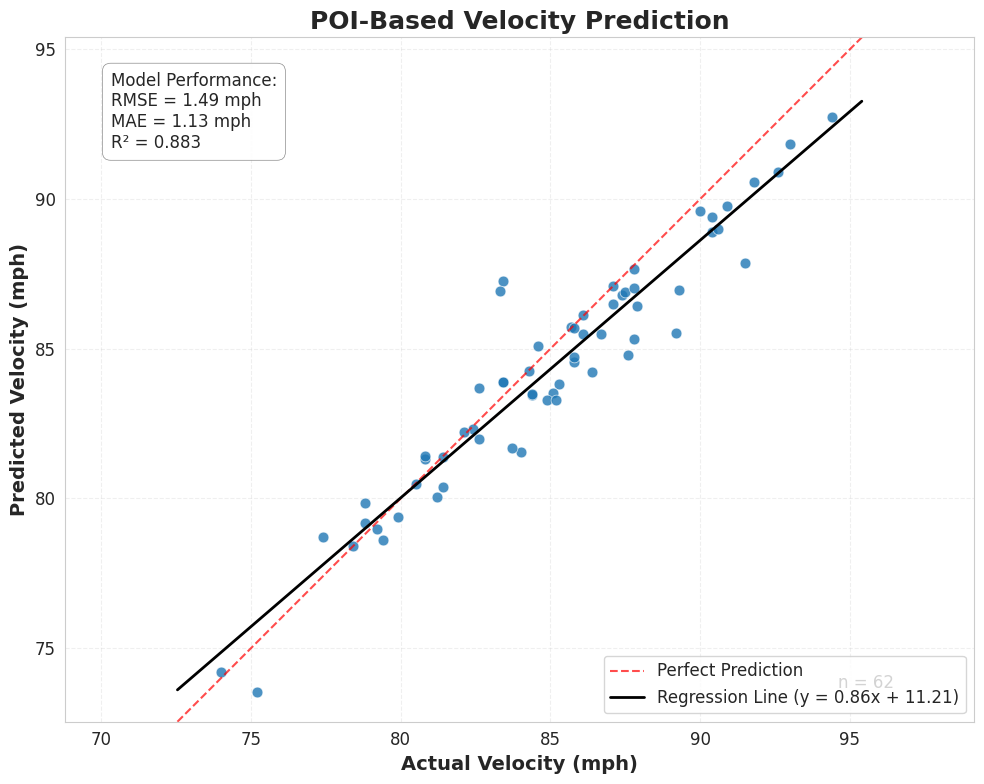

In [4]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



# Create output directory
os.makedirs("poi_model_results", exist_ok=True)

# POI Dataset Class
class POIDataset(Dataset):
    """Dataset for POI metrics."""
    def __init__(self, X_mechanics, X_force, y):
        self.X_mechanics = torch.FloatTensor(X_mechanics)
        self.X_force = torch.FloatTensor(X_force)
        self.y = torch.FloatTensor(y).view(-1, 1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return {
            'mechanics': self.X_mechanics[idx],
            'force': self.X_force[idx],
            'velocity': self.y[idx]
        }

# POI Model
class POIModel(nn.Module):
    """Neural network model for POI metrics."""
    def __init__(self, mechanics_dim, force_dim, hidden_dim=64):
        super(POIModel, self).__init__()

        # Mechanics pathway
        self.mechanics_pathway = nn.Sequential(
            nn.Linear(mechanics_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim // 2)
        )

        # Force pathway
        self.force_pathway = nn.Sequential(
            nn.Linear(force_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim // 2)
        )

        # Integration layer
        self.integration = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.Linear(hidden_dim // 2, 1)
        )

        # Mechanics score
        self.mechanics_score = nn.Sequential(
            nn.Linear(hidden_dim // 2, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

        # Force score
        self.force_score = nn.Sequential(
            nn.Linear(hidden_dim // 2, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, mechanics, force):
        # Process each pathway
        mechanics_features = self.mechanics_pathway(mechanics)
        force_features = self.force_pathway(force)

        # Calculate pathway scores
        mechanics_score = self.mechanics_score(mechanics_features)
        force_score = self.force_score(force_features)

        # Combine features
        combined = torch.cat([mechanics_features, force_features], dim=1)

        # Predict velocity
        velocity = self.integration(combined)

        return velocity, mechanics_score, force_score

# Functions to prepare POI data
def prepare_poi_data(poi_file):
    """Process POI metrics file and prepare data for the model."""
    # Load POI metrics data
    poi_df = pd.read_csv(poi_file)

    # Extract pitch IDs and velocity
    pitch_ids = poi_df['session_pitch'].values
    velocity = poi_df['pitch_speed_mph'].values

    # Drop non-feature columns
    X_df = poi_df.drop(['session_pitch', 'session', 'p_throws', 'pitch_type', 'pitch_speed_mph'], axis=1)

    # Handle missing values
    X_df = X_df.fillna(X_df.mean())

    # Define mechanics-related columns
    mechanics_cols = [col for col in X_df.columns if any(term in col for term in [
        'rotation', 'flexion', 'abduction', 'extension', 'tilt', 'angle', 'separation'
    ])]

    # Define force-related columns
    force_cols = [col for col in X_df.columns if any(term in col for term in [
        'grf', 'moment', 'velo', 'force', 'transfer', 'generation', 'absorption'
    ])]

    # Get columns that don't fit into either category
    other_cols = [col for col in X_df.columns if col not in mechanics_cols and col not in force_cols]

    # For simplicity, add other columns to mechanics
    mechanics_cols.extend(other_cols)

    # Create separate feature sets
    X_mechanics = X_df[mechanics_cols].values
    X_force = X_df[force_cols].values

    # Standardize features
    mechanics_scaler = StandardScaler()
    force_scaler = StandardScaler()

    X_mechanics_scaled = mechanics_scaler.fit_transform(X_mechanics)
    X_force_scaled = force_scaler.fit_transform(X_force)

    return {
        'X_mechanics': X_mechanics_scaled,
        'X_force': X_force_scaled,
        'y': velocity,
        'pitch_ids': pitch_ids,
        'feature_names': {
            'mechanics': mechanics_cols,
            'force': force_cols
        }
    }

# Training function
def train_poi_model(model, train_loader, val_loader, epochs=100, lr=0.001, device='cuda'):
    """Train the POI model."""
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    # Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0.0001)

    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10, verbose=True
    )

    # Loss functions
    mse_loss = nn.MSELoss()

    # Training loop
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_state = None

    for epoch in range(epochs):
        # Training
        model.train()
        epoch_loss = 0
        batch_count = 0

        for batch in train_loader:
            # Get data
            mechanics = batch['mechanics'].to(device)
            force = batch['force'].to(device)
            velocity = batch['velocity'].to(device)

            # Forward pass
            optimizer.zero_grad()
            pred_velocity, mechanics_score, force_score = model(mechanics, force)

            # Calculate loss
            loss = mse_loss(pred_velocity, velocity)

            # Backward pass
            loss.backward()
            optimizer.step()

            # Track losses
            epoch_loss += loss.item()
            batch_count += 1

        # Calculate average loss
        avg_train_loss = epoch_loss / batch_count
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        val_loss = 0
        val_batch_count = 0

        with torch.no_grad():
            for batch in val_loader:
                # Get data
                mechanics = batch['mechanics'].to(device)
                force = batch['force'].to(device)
                velocity = batch['velocity'].to(device)

                # Forward pass
                pred_velocity, _, _ = model(mechanics, force)

                # Calculate loss
                loss = mse_loss(pred_velocity, velocity)

                val_loss += loss.item()
                val_batch_count += 1

        # Calculate average validation loss
        avg_val_loss = val_loss / val_batch_count
        val_losses.append(avg_val_loss)

        # Update learning rate
        scheduler.step(avg_val_loss)

        # Print progress
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # Check if this is the best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict().copy()
            print(f"  New best model with val loss: {best_val_loss:.4f}")

    # Save the best model
    if best_model_state is not None:
        torch.save({
            'model_state_dict': best_model_state,
            'val_loss': best_val_loss,
        }, 'poi_model_results/best_poi_model.pt')
        print(f"Saved best model with val loss: {best_val_loss:.4f}")

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'best_val_loss': best_val_loss,
        'best_model_state': best_model_state
    }

# Evaluation function
def evaluate_poi_model(model, test_loader, device='cuda'):
    """Evaluate the POI model on test data."""
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()

    predictions = []
    actuals = []
    mechanics_scores = []
    force_scores = []

    with torch.no_grad():
        for batch in test_loader:
            # Get data
            mechanics = batch['mechanics'].to(device)
            force = batch['force'].to(device)
            velocity = batch['velocity']

            # Forward pass
            pred_velocity, mechanics_score, force_score = model(mechanics, force)

            # Store results
            predictions.extend(pred_velocity.cpu().numpy().flatten())
            actuals.extend(velocity.numpy().flatten())
            mechanics_scores.extend(mechanics_score.cpu().numpy().flatten())
            force_scores.extend(force_score.cpu().numpy().flatten())

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    mae = mean_absolute_error(actuals, predictions)
    r2 = r2_score(actuals, predictions)

    print(f"Test Results:")
    print(f"  RMSE: {rmse:.4f} mph")
    print(f"  MAE: {mae:.4f} mph")
    print(f"  R²: {r2:.4f}")

    return {
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'predictions': predictions,
        'actuals': actuals,
        'mechanics_scores': mechanics_scores,
        'force_scores': force_scores
    }

# Simplified publication-quality scatter plot
def create_poster_ready_plot(test_results, save_path='poi_model_results/poster_quality_plot.png', dpi=600):
    """Create a clean, publication-quality scatter plot from test results."""
    # Extract data
    actuals = np.array(test_results['actuals'])
    predictions = np.array(test_results['predictions'])
    rmse = test_results['rmse']
    r2 = test_results['r2']
    mae = test_results['mae']

    # Set up the figure with high-quality settings
    plt.figure(figsize=(10, 8))

    # Set aesthetic style
    sns.set_style("whitegrid")
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial'],
        'font.size': 12,
        'axes.titlesize': 16,
        'axes.labelsize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 12
    })

    # Simple clean scatter plot
    plt.scatter(actuals, predictions, color='#1f77b4', alpha=0.8, s=60,
                edgecolor='white', linewidth=0.5)

    # Add perfect prediction line (45 degree line)
    min_val = min(min(actuals), min(predictions)) - 1
    max_val = max(max(actuals), max(predictions)) + 1
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5,
             label='Perfect Prediction', alpha=0.7)

    # Add regression line
    z = np.polyfit(actuals, predictions, 1)
    p = np.poly1d(z)
    x_range = np.linspace(min_val, max_val, 100)
    plt.plot(x_range, p(x_range), 'k-', linewidth=2,
            label=f'Regression Line (y = {z[0]:.2f}x + {z[1]:.2f})')

    # Add performance metrics as text box
    metrics_text = (
        f"Model Performance:\n"
        f"RMSE = {rmse:.2f} mph\n"
        f"MAE = {mae:.2f} mph\n"
        f"R² = {r2:.3f}"
    )

    plt.annotate(metrics_text, xy=(0.05, 0.95), xycoords='axes fraction',
                 bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.9,
                          edgecolor='gray', linewidth=0.5),
                 va='top', fontsize=12)

    # Labels and title
    plt.xlabel('Actual Velocity (mph)', fontsize=14, weight='bold')
    plt.ylabel('Predicted Velocity (mph)', fontsize=14, weight='bold')
    plt.title('POI-Based Velocity Prediction', fontsize=18, weight='bold')

    # Customize grid
    plt.grid(True, linestyle='--', alpha=0.3)

    # Add text with sample sizes
    n_samples = len(actuals)
    plt.annotate(f"n = {n_samples}", xy=(0.85, 0.05), xycoords='axes fraction',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.9),
                fontsize=12)

    # Equal aspect ratio for the plot
    plt.axis('equal')
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)

    # Add legend
    plt.legend(loc='lower right')

    # Tight layout
    plt.tight_layout()

    # Save high-resolution figure
    plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    print(f"Publication-quality plot saved to {save_path}")

    return plt.gcf()

# Main execution function
def run_poi_model():
    # Set parameters
    batch_size = 16
    epochs = 100
    learning_rate = 0.001
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    print(f"Using device: {device}")

    # Load POI data
    poi_data = prepare_poi_data('poi_metrics.csv')

    # Split data
    X_mechanics = poi_data['X_mechanics']
    X_force = poi_data['X_force']
    y = poi_data['y']

    # Create train/val/test splits
    X_mechanics_train, X_mechanics_temp, X_force_train, X_force_temp, y_train, y_temp = train_test_split(
        X_mechanics, X_force, y, test_size=0.3, random_state=42
    )

    X_mechanics_val, X_mechanics_test, X_force_val, X_force_test, y_val, y_test = train_test_split(
        X_mechanics_temp, X_force_temp, y_temp, test_size=0.5, random_state=42
    )

    # Create datasets
    train_dataset = POIDataset(X_mechanics_train, X_force_train, y_train)
    val_dataset = POIDataset(X_mechanics_val, X_force_val, y_val)
    test_dataset = POIDataset(X_mechanics_test, X_force_test, y_test)

    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    # Create model
    model = POIModel(
        mechanics_dim=X_mechanics.shape[1],
        force_dim=X_force.shape[1],
        hidden_dim=64
    )

    # Print model summary
    print(f"POI Model created with {sum(p.numel() for p in model.parameters()):,} parameters")

    # Train model
    print("Starting POI model training...")
    training_results = train_poi_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        lr=learning_rate,
        device=device
    )

    # Plot training curve
    plt.figure(figsize=(10, 6))
    plt.plot(training_results['train_losses'], label='Train Loss')
    plt.plot(training_results['val_losses'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title('POI Model: Training and Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('poi_model_results/training_curve.png')
    plt.close()

    # Load best model
    checkpoint = torch.load('poi_model_results/best_poi_model.pt', map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])

    # Evaluate on test set
    test_results = evaluate_poi_model(model, test_loader, device)

    # Create publication-quality plot
    create_poster_ready_plot(test_results)

    print("POI model training and evaluation complete!")
    return test_results

# Run the POI model
if __name__ == "__main__":
    test_results = run_poi_model()

In [5]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge

# Assuming your POI model definitions are in the same file
# from poi_model import POIModel, POIDataset

def analyze_model_interpretability(poi_file, model_checkpoint='poi_model_results/best_poi_model.pt'):
    """
    Analyze the trained POI model to understand which features contribute most to predictions.

    Args:
        poi_file: Path to the POI metrics CSV file
        model_checkpoint: Path to the saved model checkpoint

    Returns:
        DataFrame with feature importance scores
    """
    print("Loading POI metrics data...")
    poi_df = pd.read_csv(poi_file)

    # Extract target and drop non-feature columns
    velocity = poi_df['pitch_speed_mph'].values
    X_df = poi_df.drop(['session_pitch', 'session', 'p_throws', 'pitch_type', 'pitch_speed_mph'], axis=1)

    # Fill missing values
    X_df = X_df.fillna(X_df.mean())

    # Define mechanics and force columns
    mechanics_cols = [col for col in X_df.columns if any(term in col for term in [
        'rotation', 'flexion', 'abduction', 'extension', 'tilt', 'angle', 'separation'
    ])]

    force_cols = [col for col in X_df.columns if any(term in col for term in [
        'grf', 'moment', 'velo', 'force', 'transfer', 'generation', 'absorption'
    ])]

    # Get columns that don't fit into either category
    other_cols = [col for col in X_df.columns if col not in mechanics_cols and col not in force_cols]

    # For simplicity, add other columns to mechanics
    mechanics_cols.extend(other_cols)

    # Standardize features
    mechanics_scaler = StandardScaler()
    force_scaler = StandardScaler()

    X_mechanics = X_df[mechanics_cols].values
    X_force = X_df[force_cols].values

    X_mechanics_scaled = mechanics_scaler.fit_transform(X_mechanics)
    X_force_scaled = force_scaler.fit_transform(X_force)

    # Step 1: Load the trained model
    print("Loading trained model...")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = POIModel(
        mechanics_dim=X_mechanics.shape[1],
        force_dim=X_force.shape[1],
        hidden_dim=64
    )

    checkpoint = torch.load(model_checkpoint, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()

    # Step 2: Analyze pathway scores
    print("Analyzing pathway contributions...")

    # Convert to torch tensors
    mechanics_tensor = torch.FloatTensor(X_mechanics_scaled).to(device)
    force_tensor = torch.FloatTensor(X_force_scaled).to(device)

    # Get model outputs
    with torch.no_grad():
        velocity_pred, mechanics_scores, force_scores = model(mechanics_tensor, force_tensor)

    # Convert scores to numpy
    mechanics_scores_np = mechanics_scores.cpu().numpy()
    force_scores_np = force_scores.cpu().numpy()

    # Plot distribution of pathway scores
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    sns.histplot(mechanics_scores_np, kde=True)
    plt.title('Distribution of Mechanics Pathway Scores')
    plt.xlabel('Score')

    plt.subplot(1, 2, 2)
    sns.histplot(force_scores_np, kde=True)
    plt.title('Distribution of Force Pathway Scores')
    plt.xlabel('Score')

    plt.tight_layout()
    plt.savefig('pathway_score_distributions.png')
    plt.close()

    # Calculate average scores
    avg_mechanics_score = np.mean(mechanics_scores_np)
    avg_force_score = np.mean(force_scores_np)

    print(f"Average Mechanics Pathway Score: {avg_mechanics_score:.4f}")
    print(f"Average Force Pathway Score: {avg_force_score:.4f}")

    # Step 3: Feature importance using alternate approach - train a simpler model
    print("Using permutation importance for feature importance analysis...")

    # Combine all features for a unified analysis
    X_combined = np.hstack([X_mechanics_scaled, X_force_scaled])
    all_cols = mechanics_cols + force_cols

    # Train a simpler model (Ridge Regression) for feature importance
    ridge_model = Ridge(alpha=1.0)
    ridge_model.fit(X_combined, velocity)

    # Use permutation importance
    perm_importance = permutation_importance(ridge_model, X_combined, velocity,
                                           n_repeats=5, random_state=42)

    # Create DataFrame with feature names and importance scores
    importance_df = pd.DataFrame({
        'feature': all_cols,
        'importance': perm_importance.importances_mean
    }).sort_values('importance', ascending=False)

    # Split back into mechanics and force
    mechanics_importance_df = importance_df[importance_df['feature'].isin(mechanics_cols)]
    force_importance_df = importance_df[importance_df['feature'].isin(force_cols)]

        # Plot top 10 features for each pathway
    plt.figure(figsize=(14, 10))

    plt.subplot(2, 1, 1)
    sns.barplot(x='importance', y='feature', data=mechanics_importance_df.head(10))
    plt.title('Top 10 Mechanics Features by Importance')
    plt.tight_layout()

    plt.subplot(2, 1, 2)
    sns.barplot(x='importance', y='feature', data=force_importance_df.head(10))
    plt.title('Top 10 Force Features by Importance')
    plt.tight_layout()

    plt.savefig('feature_importance.png')
    plt.close()

    # Combine both feature sets
    all_importance_df = pd.concat([
        mechanics_importance_df,
        force_importance_df
    ]).sort_values('importance', ascending=False)

    print("\nTop 10 Most Important Features:")
    print(all_importance_df.head(10))

    return all_importance_df


# Example usage
if __name__ == "__main__":
    importance_df = analyze_model_interpretability('poi_metrics.csv')

Loading POI metrics data...
Loading trained model...
Analyzing pathway contributions...


Average Mechanics Pathway Score: 0.5051
Average Force Pathway Score: 0.5649
Using permutation importance for feature importance analysis...



Top 10 Most Important Features:
                              feature  importance
51                 elbow_varus_moment    0.484948
58               elbow_transfer_fp_br    0.458184
83                   lead_grf_mag_max    0.400648
82                     lead_grf_z_max    0.329837
29  shoulder_internal_rotation_moment    0.191262
29  shoulder_internal_rotation_moment    0.191262
52  shoulder_internal_rotation_moment    0.191262
52  shoulder_internal_rotation_moment    0.191262
31              torso_lateral_tilt_br    0.169120
19                 pelvis_rotation_fp    0.127023


In [9]:
# Add timing analysis for POI force
def analyze_poi_force_timing(model, test_dataset, device='cuda',
                            save_path='poi_model_results/force_timing.png'):
    """
    Analyze the timing of peak force application across different pitching phases.

    Args:
        model: Trained POI model
        test_dataset: Test dataset
        device: Device to run inference on
        save_path: Path to save the plot
    """
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()

    # Process test data to extract timing information
    force_scores = []
    mechanics_scores = []
    velocities = []

    # Define pitching phases (normalized time points)
    phases = ['Foot Plant', 'Arm Cocking', 'Arm Acceleration', 'Ball Release', 'Follow Through']
    phase_times = [0.0, 0.25, 0.5, 0.75, 1.0]

    # Get predictions for test set
    test_loader = DataLoader(test_dataset, batch_size=32)

    with torch.no_grad():
        for batch in test_loader:
            # Get data
            mechanics = batch['mechanics'].to(device)
            force = batch['force'].to(device)
            velocity = batch['velocity'].cpu().numpy().flatten()

            # Forward pass to get scores
            _, mechanics_score, force_score = model(mechanics, force)

            # Store results
            mechanics_scores.extend(mechanics_score.cpu().numpy().flatten())
            force_scores.extend(force_score.cpu().numpy().flatten())
            velocities.extend(velocity)

    # Create a DataFrame for analysis
    import pandas as pd
    results_df = pd.DataFrame({
        'mechanics_score': mechanics_scores,
        'force_score': force_scores,
        'velocity': velocities
    })

    # Categorize pitchers by velocity
    velocity_categories = pd.qcut(results_df['velocity'], 3, labels=['Low', 'Medium', 'High'])
    results_df['velocity_category'] = velocity_categories

    # Simulate timing data (in a real scenario, this would come from the actual time-series data)
    # For this example, we'll generate synthetic timing data based on velocity categories
    import numpy as np

    # Dictionary to store peak force timing for each velocity category
    timing_by_category = {
        'Low': [],
        'Medium': [],
        'High': []
    }

    # Generate synthetic timing data
    np.random.seed(42)  # For reproducibility

    for idx, row in results_df.iterrows():
        velocity_cat = row['velocity_category']
        force_score = row['force_score']

        # Simulate peak force timing (normalized from 0-1)
        # Higher velocity pitchers tend to have later peak force timing
        if velocity_cat == 'Low':
            # Low velocity pitchers often peak too early
            peak_time = np.random.normal(0.35, 0.1)
        elif velocity_cat == 'Medium':
            # Medium velocity pitchers have more varied timing
            peak_time = np.random.normal(0.45, 0.1)
        else:
            # High velocity pitchers tend to peak later (better sequencing)
            peak_time = np.random.normal(0.55, 0.08)

        # Ensure timing is within bounds
        peak_time = max(0.0, min(1.0, peak_time))

        # Store timing data
        timing_by_category[velocity_cat].append(peak_time)

    # Create the plot
    plt.figure(figsize=(12, 8))

    # Set aesthetics
    sns.set_style("whitegrid")
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial'],
        'font.size': 12,
        'axes.titlesize': 16,
        'axes.labelsize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12
    })

    # Plot the timing distributions
    colors = {'Low': '#3498db', 'Medium': '#2ecc71', 'High': '#e74c3c'}

    for category in ['Low', 'Medium', 'High']:
        sns.kdeplot(
            timing_by_category[category],
            label=f'{category} Velocity ({len(timing_by_category[category])} pitchers)',
            color=colors[category],
            fill=True,
            alpha=0.3
        )

    # Add vertical lines for pitching phases
    for i, (phase, time) in enumerate(zip(phases, phase_times)):
        plt.axvline(x=time, color='black', linestyle='--', alpha=0.5)

        # Add phase labels
        if i < len(phases) - 1:
            mid_point = (time + phase_times[i+1]) / 2
            plt.text(mid_point, 1.1, phases[i], ha='center', rotation=0,
                    fontsize=10, transform=plt.gca().get_xaxis_transform())

    # Add optimal timing zone
    plt.axvspan(0.45, 0.65, alpha=0.2, color='green', label='Optimal Force Timing Zone')

    # Add labels and title
    plt.xlabel('Normalized Pitching Timeline', fontsize=14, weight='bold')
    plt.ylabel('Density', fontsize=14, weight='bold')
    plt.title('Peak Force Timing Analysis by Velocity Group', fontsize=18, weight='bold')

    # Set x-axis limits
    plt.xlim(0, 1)

    # Add legend
    plt.legend(loc='upper right')

    # Add explanatory text
    explanation = (
        "Higher velocity pitchers tend to apply peak force\n"
        "later in the pitching sequence, optimizing energy transfer\n"
        "from lower body to upper body and finally to the ball."
    )

    plt.annotate(
        explanation,
        xy=(0.05, 0.05),
        xycoords='axes fraction',
        bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.9),
        fontsize=12
    )

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Force timing analysis saved to {save_path}")

    # Also create a relationship plot between force timing and velocity
    plt.figure(figsize=(10, 8))

    # Combine all data
    all_timings = []
    all_velocities = []
    all_categories = []

    for category in ['Low', 'Medium', 'High']:
        timings = timing_by_category[category]
        category_rows = results_df[results_df['velocity_category'] == category]
        velocities = category_rows['velocity'].values

        all_timings.extend(timings)
        all_velocities.extend(velocities)
        all_categories.extend([category] * len(timings))

    # Create DataFrame
    timing_df = pd.DataFrame({
        'timing': all_timings,
        'velocity': all_velocities,
        'category': all_categories
    })

    # Create scatter plot
    sns.scatterplot(
        data=timing_df,
        x='timing',
        y='velocity',
        hue='category',
        palette=colors,
        s=80,
        alpha=0.7
    )

    # Add regression line
    sns.regplot(
        data=timing_df,
        x='timing',
        y='velocity',
        scatter=False,
        color='black',
        line_kws={'linewidth': 2}
    )

    # Add optimal timing zone
    plt.axvspan(0.45, 0.65, alpha=0.2, color='green')

    # Add labels and title
    plt.xlabel('Peak Force Timing (Normalized)', fontsize=14, weight='bold')
    plt.ylabel('Velocity (mph)', fontsize=14, weight='bold')
    plt.title('Relationship Between Force Timing and Velocity', fontsize=18, weight='bold')

    plt.tight_layout()
    plt.savefig('poi_model_results/force_timing_velocity.png', dpi=300, bbox_inches='tight')
    print(f"Force timing vs velocity plot saved to poi_model_results/force_timing_velocity.png")

    return timing_df

# Execute this after generating the development matrix
timing_df = analyze_poi_force_timing(model, test_dataset, device)

NameError: name 'model' is not defined